# Table of contents

* **Introduction**
* **Objective**
* **Convolutional Neural Networks (CNNs) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Data visualization**
* **Feature Engineering**
* **Model Training**
    * Model Architecture, Model Building (Pytorch), and Model Training
* **Model Evaluation**
* **References**

# Introduction

This tutorial demonstrates the construction, training, and evaluation of a Convolutional Neural Network (CNN) utilizing PyTorch for the multi-class classification task on the FashionMNIST dataset. The dataset comprises 70,000 grayscale images, each $\mathbf{28 \times 28}$ pixels, distributed across 10 distinct clothing categories. The goal is to accurately classify these images using a CNN implemented from scratch, demonstrating proficiency in PyTorch's data handling, model definition, regularization techniques like early stopping, and advanced model interpretability.

# Objective

The primary objective is the implementation of a CNN within the PyTorch ecosystem that successfully learns the hierarchical features inherent in the FashionMNIST images to classify them into the 10 fashion classes, ensuring both high accuracy and strong generalization. The methodology prioritizes modular dataset handling, establishing an explicit training/validation data split, employing early stopping for regularization, and conducting a comprehensive evaluation. Furthermore, the project includes crucial interpretability tools, such as the visualization of learned convolutional filters and the projection of decision boundaries onto a PCA-reduced latent space.

# Convolutional Neural Networks (CNNs) Foundations

A Convolutional Neural Network (CNN) is a specialized type of deep learning model primarily designed to process and analyze structured grid-like data, such as images. They are highly effective at automatically learning spatial hierarchies of features from low-level details (edges and textures) to high-level concepts (objects and faces).

**How CNNs Work**

A CNN operates by applying a sequence of specialized layers to the input data. Its effectiveness stems from three fundamental concepts: sparse connectivity, parameter sharing, and equivariant representations.

**Convolutional Layer (Feature Extraction)**

This is the core building block of a CNN. It performs feature extraction by detecting patterns in local regions of the input:

- Kernel (Filter): A small matrix of weights (e.g., $3 \times 3$) that slides across the input data (e.g., an image). The kernel performs an element-wise multiplication with the small region of the input it covers, and the results are summed up to produce a single output value.
- Convolution Operation: This sliding process generates a new matrix called a feature map (or activation map), which highlights where specific features (like vertical edges or corners) are located in the input.
- Activation Function (ReLU): Immediately after the convolution, a non-linear activation function, typically the Rectified Linear Unit ($\text{ReLU}(z) = \max(0, z)$), is applied element-wise to the feature map. This introduces non-linearity, allowing the network to learn more complex relationships.

**Pooling Layer (Dimensionality Reduction)**

This layer is inserted between successive convolutional layers to progressively reduce the spatial dimensions (width and height) of the feature maps, which helps to:
- Reduce Computational Load: Fewer parameters and computations are needed in subsequent layers.
- Control Overfitting: Simplifies the model.
- Achieve Translation Invariance: The network becomes more robust to small shifts or distortions in the input image.

The most common method is Max Pooling, which takes the maximum value from a cluster of neurons in the feature map, thus retaining the most prominent feature response in that local region.

**Fully Connected Layer (Classification)** 

After several alternating convolutional and pooling layers have extracted complex features, the final feature maps are flattened into a single vector. This vector is fed into one or more standard Fully Connected (Dense) layers. These layers, identical to those in a traditional neural network, use the high-level features learned by the CNN layers to perform the final classification task (e.g., deciding if the image contains a cat, dog, or car).

**Types of Convolutional Neural Networks**

The term "types" of CNN often refers to different architectural variants that adapt the standard CNN structure for various tasks or data types. Some of the most notable types and architectures include:

**1. By Dimensionality of Convolution**

This categorization depends on the shape of the data and the direction the filter slides:
- 1D CNN: Used for sequence data like time-series or signals (e.g., audio, medical data, natural language processing). The filter slides along a single dimension.
- 2D CNN: The standard form, used for images (2D grids). The filter slides across the height and width of the input.
- 3D CNN: Used for volumetric data (like MRI scans) or video (which adds a temporal dimension to space). The filter slides across height, width, and depth (or time).

**2. By Architecture and Design Principles**

These are specialized designs optimized for specific performance goals (depth, speed, or accuracy):
- LeNet: One of the earliest and foundational CNN architectures, primarily used for handwritten digit recognition.
- AlexNet: A pioneering deep CNN that demonstrated the power of the model on large-scale datasets (ImageNet), featuring multiple convolutional layers, ReLU activation, and local response normalization.
- VGGNet: Known for its simplicity, using very small ($3 \times 3$) filters throughout the entire network, emphasizing the depth of the network.
- ResNet (Residual Network): Introduced Skip Connections (or residual connections) to allow the gradient to flow around non-linear layers. This solved the degradation problem, enabling the training of extremely deep networks (hundreds of layers).
- Inception (GoogLeNet): Introduced the Inception Module, which performs multiple parallel convolutions (with $1 \times 1, 3 \times 3, 5 \times 5$ kernels, and pooling) on the same input block.This allows the network to automatically choose the best convolutional size for the input data.
- MobileNet / EfficientNet: Designed for mobile and embedded vision applications. They prioritize efficiency and speed by using techniques like depthwise separable convolutions to drastically reduce the number of parameters and computational cost while maintaining high accuracy

# Data Dictionary

**About Dataset**

Image Format is a single row in the CSV file. The first column is the label (0-9, representing the clothing type). Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255. The training and test data sets have 785 columns. The first column consists of the class labels (see above), and represents the article of clothing. The rest of the columns contain the pixel-values of the associated image. Training and Test sets contains 60,000 and 10,000 images, respectively.

To locate a pixel on the image, suppose that we have decomposed $x$ as $x = i * 28 + j$, where i and j are integers between 0 and 27. The pixel is located on row i and column j of a 28 x 28 matrix.
For example, pixel31 indicates the pixel that is in the fourth column from the left, and the second row from the top, as in the ascii-diagram below.

**Labels**

Each training and test example is assigned to one of the following labels:

* 0 T-shirt/top
* 1 Trouser
* 2 Pullover
* 3 Dress
* 4 Coat
* 5 Sandal
* 6 Shirt
* 7 Sneaker
* 8 Bag
* 9 Ankle boot

**[Dataset Link](https://www.kaggle.com/datasets/zalando-research/fashionmnist)**

# Pipeline Overview

The project is structured into a logical, sequential workflow:
- Data Loading & Exploration: Initial steps involve ingesting the data files, examining their structure, and performing visual checks on both sample images and the distribution of pixel intensities.
- Preprocessing: The raw data is prepared for the neural network through steps like normalization, reshaping into the required $\mathbf{C, H, W}$ tensor format, and converting the arrays to appropriate PyTorch tensors.
- Dataset & DataLoader Setup: Custom PyTorch Dataset and DataLoader objects are configured. This includes splitting the training data into separate training and validation sets and setting up efficient batching and shuffling.
- Modeling: The CNN architecture is constructed, comprising sequential convolutional and pooling blocks for feature extraction, followed by fully connected layers for classification.
- Training: The model is iteratively optimized using a defined loss function and optimizer, with the training loop incorporating validation and using early stopping to manage performance and prevent overfitting.
- Evaluation: The model's generalization capability is formally assessed on the reserved test set using a wide array of metrics, including $\text{AUC}$, $\text{F1}$-scores, and a $\text{Confusion Matrix}$.Interpretability: Visual analysis is conducted on the model's internal representations, specifically focusing on the $\mathbf{learned\ filters}$ and the decision boundaries projected onto a $\mathbf{2D\ PCA}$ space.

# Approach

**Preprocess Pipeline Approach**

The preprocessing methodology focuses on preparing raw pixel data for PyTorch's computational requirements:
- Data Preparation: The pixel features and corresponding labels are loaded and separated from the raw CSV data files.
- Scaling: Pixel values are normalized by scaling them from their original $\mathbf{[0, 255]}$ range to $\mathbf{[0, 1]}$, which is a standard practice to stabilize and accelerate training convergence.
- Formatting: The flattened pixel vectors are reshaped to the channels-first format ($\mathbf{C, H, W}$) that PyTorch's convolutional layers require.
- Tensorization: The prepared data arrays are finally converted to PyTorch tensors with appropriate data types for model consumption.

**Model Training Approach**

The training process leverages PyTorch's native utilities for efficient and controlled learning:
- Data Abstraction: A custom Dataset class is defined to handle data indexing and retrieval, and the total training data is formally divided into dedicated training and validation subsets.
- Batch Management: DataLoaders are established to manage the flow of data, enabling efficient mini-batch processing and ensuring data is shuffled during training iterations.
- Architecture Implementation: The CNN is implemented using the `nn.Module` base class, structuring the network with alternating convolutional and max pooling operations followed by dense layers.
- Optimization Setup: An `Adam` optimizer is configured alongside the `CrossEntropyLoss` function, which is the standard choice for multi-class classification.
- Training Control: The training loop is designed to run for a maximum number of epochs but is primarily controlled by a validation-monitored Early Stopping callback that restores the model to its best-performing state to prevent degradation from overfitting.

**Model Evaluation Approach**

Evaluation is comprehensive, moving beyond simple accuracy to assess robustness and generalization across all classes:
- Final Assessment: The model's ultimate performance is determined by running a single final evaluation pass on the independent test dataset to report the definitive loss and accuracy.
- Prediction Metrics: Inference is run on the test set to collect all necessary prediction data (true labels, predicted labels, and probability scores) for subsequent metric calculation.
- Metric Suite: Key metrics are computed, including overall accuracy, macro-averaged scores for precision, recall, and $\mathbf{F1}$-score, and the multi-class $\mathbf{ROC-AUC}$. A detailed classification report provides per-class performance breakdowns.
- Visual Analysis: Errors are visualized via a Confusion Matrix, and the model's predictive certainty is analyzed through per-class Precision-Recall curves with $\mathbf{AUC}$ scores.
- Interpretability Deep Dive: The features from an intermediate layer are subjected to $\mathbf{PCA}$ reduction for visualization, allowing the decision boundaries and latent space clustering to be plotted, thereby revealing the learned feature separation.

# Setup Environments

**Import Libraries**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, ReLU, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    auc,
    roc_curve
)
from sklearn.decomposition import PCA

print(f"PyTorch Version: {torch.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

2025-11-12 18:04:41.506297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762970681.760115      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762970681.836634      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


PyTorch Version: 2.6.0+cu124
TensorFlow Version: 2.18.0


# Data Loading

The initial step in data analysis involves loading the dataset and examining its fundamental structure and characteristics.

**Data Loading:** The training and testing datasets are ingested directly from their CSV files using the pandas library, forming two distinct $\mathbf{DataFrame}$ objects.

In [3]:
train = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_test.csv')
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Exploratory Data Analysis (EDA)

**Basic Information**

**Structure Examination:** The `train.info()` function provides a summary of the data structure. It confirms the dataset contains $\mathbf{60,000}$ entries, indexed from 0 to 59999. Crucially, it verifies that there are $\mathbf{785}$ columns—one for the label and $\mathbf{784}$ for the pixels ($\mathbf{28 \times 28}$), all of which are of the integer type ($\mathbf{int64}$). The check also confirms that no missing values are present, as the non-null count matches the total entry count.

In [4]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


**Descriptive Statistics:** The `train.describe()` function computes central tendency, dispersion, and shape of the dataset's distribution. The key focus here is on the pixel columns ($\mathbf{pixel1}$ through $\mathbf{pixel784}$), where the values range from a $\mathbf{minimum}$ of $\mathbf{0}$ to a $\mathbf{maximum}$ of $\mathbf{255}$, conforming to the standard range for $\mathbf{8-bit\ grayscale\ images}$. The statistics reveal that the mean pixel values are generally close to zero for most pixel columns, indicating that a significant portion of the image area, particularly the borders, consists of the black background.

In [6]:
train.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


**Distribution of Pixel Intensities**

Pixel Intensity DistributionThe distribution of pixel values across all images is visualized to understand the overall content structure.
- Data Preparation: The label column is dropped, and all $\mathbf{784}$ pixel columns are flattened into a single, massive array containing $\mathbf{47,040,000}$ pixel values ($\mathbf{60,000 \times 784}$).
- Visualization: A $\mathbf{histogram}$ with a Kernel Density Estimate (KDE) overlay is plotted using a large number of bins to display the frequency of each intensity value between $\mathbf{0}$ and $\mathbf{255}$. This visual check is fundamental for anticipating the need for normalization during preprocessing.


--- Distribution of Pixel Intensities in Training Data ---
Shape of all_pixel_values: (47040000,)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


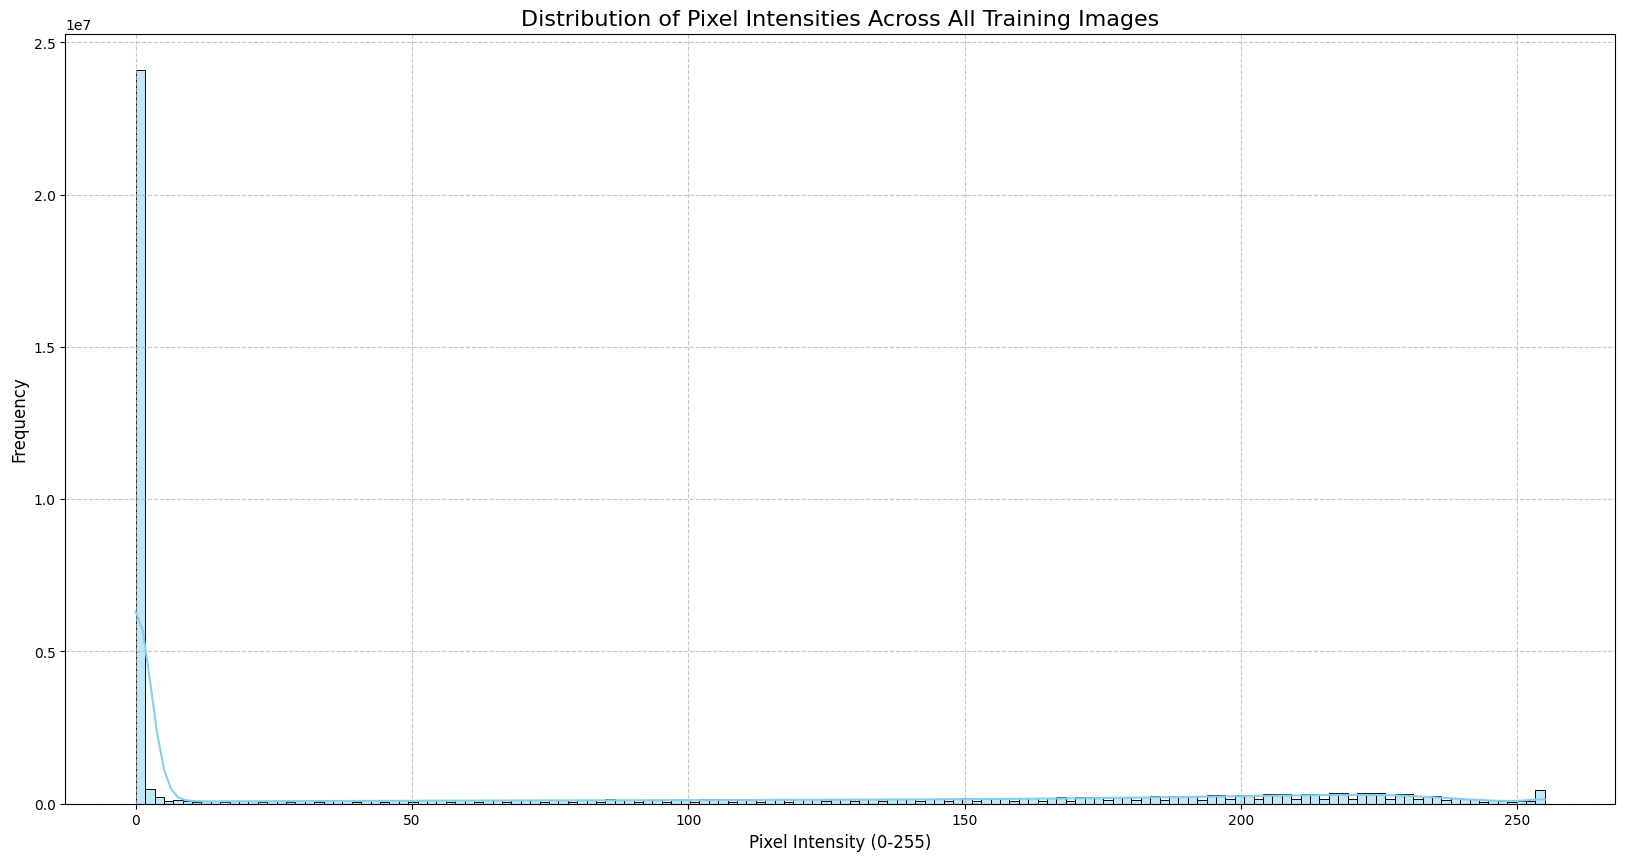

In [ ]:
print("\n--- Distribution of Pixel Intensities in Training Data ---")

pixel_data = train.drop('label', axis=1)

all_pixel_values = pixel_data.values.flatten()

all_pixel_values = all_pixel_values[~np.isinf(all_pixel_values)]
all_pixel_values = all_pixel_values[~np.isnan(all_pixel_values)]

print(f"Shape of all_pixel_values: {all_pixel_values.shape}")
if all_pixel_values.size > 0:
    plt.figure(figsize=(20, 10))
    sns.histplot(all_pixel_values, bins=150, kde=True, color='skyblue')
    plt.title('Distribution of Pixel Intensities Across All Training Images', fontsize=16)
    plt.xlabel('Pixel Intensity (0-255)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No pixel data available to plot the distribution.")

The distribution of pixel intensities is highly skewed, exhibiting a massive peak near $\mathbf{0}$ (black) and a secondary, but much smaller, cluster of higher intensity values toward $\mathbf{255}$ (white).
- Background Dominance: The dominant peak at $\mathbf{0}$ indicates that a vast majority of the pixels across all images are $\mathbf{background}$. The images are sparse, meaning the actual garment only occupies a small portion of the total $\mathbf{28 \times 28}$ canvas.
- Normalization Rationale: This intensity range ($\mathbf{0}$ to $\mathbf{255}$) confirms the necessity of normalization (scaling to $\mathbf{[0, 1]}$) before model training to prevent large input values from causing instability or excessively slow convergence of the gradient descent optimization process.

**Target Label Distribution**

Target Label DistributionThe balance of the classification task is assessed by analyzing the distribution of the target variable.
- Value Counts: The $\mathbf{label}$ column's value counts are calculated and normalized to represent the percentage of samples belonging to each of the $\mathbf{10}$ classes.
- Interpretation: This check confirms whether the dataset is balanced (equal representation) or imbalanced (skewed representation), which directly impacts the choice of evaluation metrics later in the project.

In [7]:
label = train['label']
label = set(label)
label

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [8]:
train['label'].value_counts(normalize=True)*100

label
2    10.0
9    10.0
6    10.0
0    10.0
3    10.0
4    10.0
5    10.0
8    10.0
7    10.0
1    10.0
Name: proportion, dtype: float64

The target label distribution analysis reveals a perfectly balanced dataset.
- Equal Representation: Each of the $\mathbf{10}$ clothing categories (0 through 9) accounts for exactly $\mathbf{10.0\%}$ of the total training samples.
- Metric Choice: This balance is advantageous as it means that simple accuracy can be reliably used as a primary evaluation metric. However, the subsequent use of metrics like $\mathbf{F1-score}$, $\mathbf{Precision}$, and $\mathbf{Recall}$ remains essential for a more granular understanding of classification errors.

**Dataset Visualization**

Visualization of sample images provides immediate qualitative insight into the data and the difficulty of the classification task.
- Sampling and Reshaping: For each unique class label (0 through 9), a single image sample is selected. The corresponding $\mathbf{784}$ pixel values are reshaped from the flattened vector form into the $\mathbf{28 \times 28}$ two-dimensional image matrix.
- Display: The images are displayed in a grid format using a grayscale color map (with intensity range 0 to 255) and labeled with their descriptive class names. This serves as an initial check on the data quality and the visual similarity between different categories.

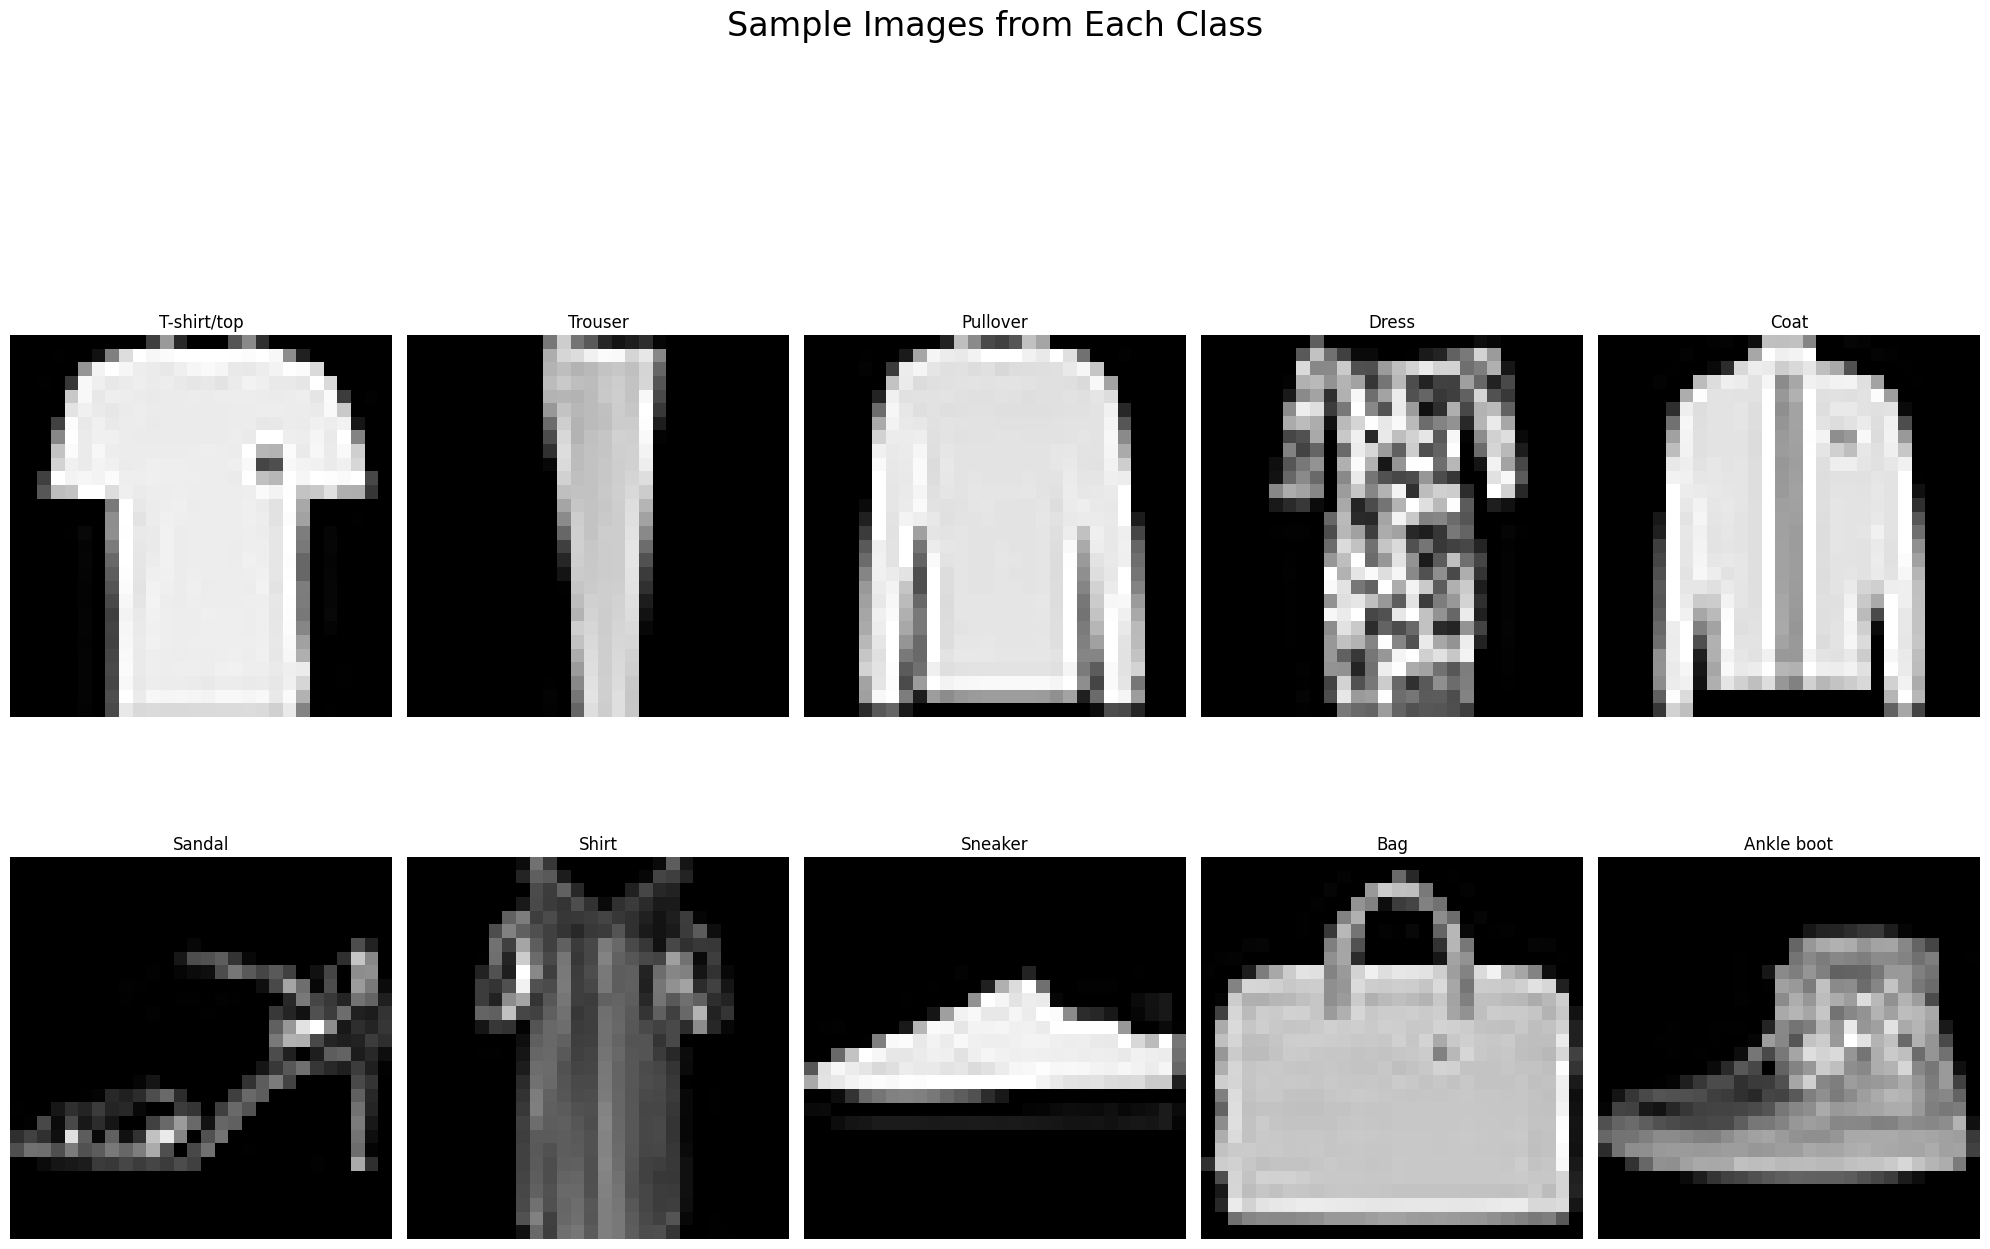

In [ ]:
y = train['label']

pixel_cols = train.drop('label', axis=1).columns.tolist()

label_dict = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

plt.figure(figsize=(20, 15))
for i, class_id in enumerate(label_dict.keys()):
    plt.subplot(2, 5, i + 1)

    if isinstance(y, pd.Series):
        samples_for_class = train.loc[y == class_id, pixel_cols]
    else:
        samples_for_class = train.loc[pd.Series(y) == class_id, pixel_cols]

    if not samples_for_class.empty:
        sample = samples_for_class.sample(1)
        image_array = np.reshape(sample.values[0], (28, 28))

        plt.gca().imshow(image_array, cmap='gray', vmin=0, vmax=255)
        plt.title(label_dict[class_id])
        plt.axis('off')
    else:
        plt.title(f"No samples for {label_dict[class_id]}")
        plt.axis('off')

plt.suptitle('Sample Images from Each Class\n', fontsize=24)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The visual examination of sample images provides qualitative context for the classification challenge.
- Distinct Classes: Categories such as $\mathbf{Trouser}$ (1), $\mathbf{Bag}$ (8), $\mathbf{Sneaker}$ (7), and $\mathbf{Ankle boot}$ (9) display highly distinct and consistent shapes. These classes are expected to be easily classified by the CNN.
- Confusable Classes: Visual similarity is high among the top wear categories, specifically $\mathbf{T-shirt/top}$ (0), $\mathbf{Pullover}$ (2), $\mathbf{Coat}$ (4), and $\mathbf{Shirt}$ (6). Distinguishing between these classes often relies on subtle texture or sleeve length features, suggesting that the model may experience higher misclassification rates in these specific areas, which would be visible in the Confusion Matrix during evaluation.

# Feature Engineering

This stage of the machine learning pipeline focuses on transforming the raw tabular data into a format suitable for consumption by a PyTorch Convolutional Neural Network (CNN).

**Features and Target Label Splitting**

The initial step involves clearly delineating the independent variables (features, $\mathbf{X}$) from the dependent variable (target label, $\mathbf{y}$).
- Extraction: The $\mathbf{label}$ column, which contains the class identity for each image, is separated from the $\mathbf{784}$ pixel columns. This process is performed independently for both the training and test datasets.
- Purpose: This separation is fundamental to supervised learning, ensuring the model is trained to predict the $\mathbf{y}$ values based solely on the $\mathbf{X}$ values. The resulting shapes confirm $\mathbf{60,000}$ training samples and $\mathbf{10,000}$ test samples, each with $\mathbf{784}$ features.

In [ ]:
x_train_raw = train.drop('label', axis=1)
y_train_raw = train['label']
x_test_raw = test.drop('label', axis=1)
y_test_raw = test['label']

print("X_train shape:", x_train_raw.shape)
print("y_train shape:", y_train_raw.shape)
print("X_test shape:", x_test_raw.shape)
print("y_test shape:", y_test_raw.shape)

X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


**Data Normalization**

Data standardization is a crucial preprocessing step for neural networks, followed by reshaping to meet the input requirements of convolutional layers.
- Normalization: Pixel values, initially ranging from $\mathbf{0}$ to $\mathbf{255}$, are normalized by dividing by the maximum possible intensity value ($\mathbf{255.0}$). This scales all features into the consistent range of $\mathbf{[0, 1]}$. This practice significantly aids the convergence of the optimization algorithm (e.g., Stochastic Gradient Descent or Adam) by ensuring that feature scales do not disproportionately influence the gradient updates.
- Reshaping for CNNs: Convolutional Neural Networks operate on input tensors with a specific rank and dimension ordering, often referred to as $\mathbf{(N, C, H, W)}$, where:
    - $\mathbf{N}$ is the Batch Size (in this case, represented by $\mathbf{-1}$ to denote all samples).
    - $\mathbf{C}$ is the Number of Channels. For grayscale images like FashionMNIST, $\mathbf{C = 1}$.
    - $\mathbf{H}$ and $\mathbf{W}$ are the Height and Width of the image ($\mathbf{28 \times 28}$).
    - The $\mathbf{784}$ feature vector for each image is reshaped to $\mathbf{(1, 28, 28)}$. This conversion of flat pixel data back into a 3D volume (including the channel dimension) is essential for the spatial filters (kernels) of the CNN to perform convolution.

In [ ]:
x_train_normalized = x_train_raw.values / 255.0
x_test_normalized = x_test_raw.values / 255.0

x_train_cnn = x_train_normalized.reshape(-1, 1, 28, 28)
x_test_cnn = x_test_normalized.reshape(-1, 1, 28, 28)

**PyTorch Tensor Conversion**

The final preparation stage converts the NumPy arrays into the proprietary data structures required by the PyTorch framework.
- Tensor Concept: A Tensor is PyTorch's fundamental data structure, analogous to NumPy's `ndarray`, optimized for operations on accelerators like GPUs.
- Data Type Assignment: Specific data types are assigned according to PyTorch conventions for deep learning:
    - Features (`x_tensors`): Pixel data requires high precision for calculation and is cast to torch.float32.
    - Labels (`y_tensors`): The target class indices (0 to 9) are integer categories and must be cast to torch.long (`64-bit integer`) to be compatible with PyTorch's standard `CrossEntropyLoss` function.

In [ ]:
x_train_tensor = torch.tensor(x_train_cnn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_raw.values, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_cnn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_raw.values, dtype=torch.long)

num_classes = len(np.unique(y_train_raw.values))

print(f"x_train_tensor shape: {x_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"x_test_tensor shape: {x_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")
print(f"Number of classes: {num_classes}")
print("="*40 + "\n")

x_train_tensor shape: torch.Size([60000, 1, 28, 28])
y_train_tensor shape: torch.Size([60000])
x_test_tensor shape: torch.Size([10000, 1, 28, 28])
y_test_tensor shape: torch.Size([10000])
Number of classes: 10



**Verification:** The resulting tensor shapes confirm the required $\mathbf{(N, C, H, W)}$ format for the features ($\mathbf{60000, 1, 28, 28}$ and $\mathbf{10000, 1, 28, 28}$) and the number of classes ($\mathbf{10}$), indicating successful preparation for the CNN model.

# Model Training

## Model Architecture, Model Building (Pytorch), and Model Training

The process of preparing data and constructing a Convolutional Neural Network (CNN) in PyTorch follows a rigorous methodology rooted in object-oriented design, centering on the Dataset and DataLoader abstractions and the `nn.Module` class.

**Data Handling with Dataset and DataLoader**

In PyTorch, data processing is decoupled from the model architecture through two key classes:

**1. Custom Dataset**

The `FashionMNISTDataset` class inherits from PyTorch’s abstract Dataset class. This custom class serves as a fundamental interface for accessing individual data samples. It encapsulates the features (the image tensors, `x`) and the labels (`y`).
- The `__len__` method defines the size of the dataset, allowing the framework to know the total number of samples available.
- The `__getitem__` method is essential, providing the mechanism to fetch a single data point (an image-label pair) given an index (`idx`). This allows for efficient, random access to any sample, which is a prerequisite for stochastic optimization algorithms.

**2. Data Splitting and Loading**

After creating the `full_train_dataset`, it is crucial to perform data splitting to ensure proper model validation.
- The `random_split` utility divides the initial training set into a dedicated training set (e.g., 80% of data) and a separate validation set (e.g., 20%). This partition is vital for assessing the model's generalization ability during training and preventing overfitting.
- The `DataLoader` class is then used to wrap the Dataset objects. The DataLoader's primary function is to efficiently load data in batches (here, a size of 64) and manage other logistics like shuffling and parallel data loading (multiprocessing). Shuffling the training data (`shuffle=True`) at the beginning of each epoch randomizes the order in which the model sees the samples, which is necessary to break potential correlations within the dataset and improve the robustness of Stochastic Gradient Descent (SGD).

**CNN Model Definition in PyTorch**

The Convolutional Neural Network architecture is defined by inheriting from PyTorch’s base class for all neural network modules, nn.Module.

**1. Model Initialization (`__init__`)**

The model's `__init__` method defines all the layers and sub-modules that the network will use. This architecture closely mirrors the requested CNN structure:
- Convolutional Blocks: Two blocks are constructed, each containing a nn.Conv2d layer for feature detection, followed by a nn.ReLU activation function, and then a nn.MaxPool2d layer for spatial dimension reduction.
    - The first convolutional layer (`conv1`) takes 1 input channel (grayscale) and produces 32 output channels. After max pooling, the dimensions are halved (from $28\times28$ to $14\times14$).
    - The second convolutional layer (`conv2`) takes 32 input channels and produces 64 output channels. Subsequent pooling reduces dimensions further (from $14\times14$ to $7\times7$).
- Fully Connected Layers: The network transitions from spatial feature maps to standard dense vectors using three nn.Linear layers. The input size to the first linear layer (`fc1`) is calculated by flattening the final feature map: $64 \text{ channels} \times 7 \times 7 = 3136$ features. A subsequent intermediate layer (`fc_intermediate`) adds depth, and the final output layer (`fc_output`) maps the features to the 10 classification classes.

**2. Forward Pass (forward)**

The forward method defines the sequential flow of data through the layers. It dictates the order in which operations are performed during a forward propagation step:
- The input image tensor ($\mathbf{x}$) passes through the convolutional and pooling blocks.
- Before entering the fully connected section, the tensor is flattened using the `x.view(-1, ...)` operation. This converts the 4D feature map tensor into a 2D tensor (`batch_size * 3136`) required by the linear layers. The dimension $-1$ automatically determines the batch size.
- The data then passes through the fully connected layers, resulting in a final tensor of shape `batch_size} * 10`, representing the raw logits for each class.

The final step is to leverage available hardware; the model is explicitly moved to a computational device (GPU, or `"cuda"`, if available, otherwise the CPU) to accelerate the complex matrix operations.

**Loss Function, Optimizer, and Training**

**Optimization Components**

- Loss Function: The `nn.CrossEntropyLoss()` is selected. This function is perfectly suited for multi-class classification and efficiently combines the Softmax operation (to convert logits to probabilities) and the Negative Log-Likelihood loss into a single, numerically stable operation.
- Optimizer: The `optim.Adam` optimizer is utilized. Adam is an adaptive learning rate optimization algorithm that computes individual adaptive learning rates for different parameters, which generally leads to faster convergence and better performance compared to standard SGD.

**Training Loop and Early Stopping**

The training process iterates over a predefined number of epochs. Within each epoch, the data is processed in batches by the `train_loader`.

- Gradient Reset: Before each batch iteration, `optimizer.zero_grad()` is called to clear the gradients accumulated from the previous iteration, ensuring they do not interfere with the current update.
- Forward Pass: The data moves through the model (`outputs = model(images)`).
- Loss Calculation: The loss between the model's prediction and the true labels is computed.
- Backpropagation: `loss.backward()` computes the gradients of the loss with respect to every trainable parameter in the model.
- Parameter Update: `optimizer.step()` updates the model's weights using the computed gradients and the Adam optimization rules.

Early Stopping is implemented as a crucial regularization technique. It monitors the validation loss at the end of each epoch. If the validation loss fails to decrease for a specified number of consecutive epochs (the patience value, set to 8), the training loop is terminated. This prevents the model from continuing to train into a region of high overfitting, and the best-performing model weights, saved when the validation loss was at its minimum, are restored. This mechanism ensures optimal generalization performance on unseen data.

In [ ]:
class FashionMNISTDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

full_train_dataset = FashionMNISTDataset(x_train_tensor, y_train_tensor)
test_dataset = FashionMNISTDataset(x_test_tensor, y_test_tensor)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")
print("="*40 + "\n")

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu3 = nn.ReLU()
        self.fc_intermediate = nn.Linear(128, 64)
        self.relu_intermediate = nn.ReLU()
        self.fc_output = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu3(self.fc1(x))
        x = self.relu_intermediate(self.fc_intermediate(x))
        x = self.fc_output(x)
        return x

model = CNN(num_classes=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("\n--- CNN Model Architecture ---")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {total_params}")
print(f"Using device: {device}")
print("="*40 + "\n")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 100
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

early_stopping_patience = 8
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

print("--- Starting Training ---")
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_accuracy = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f'Early stopping triggered at epoch {epoch+1}. No improvement for {early_stopping_patience} epochs.')
            model.load_state_dict(best_model_state)
            break

    print(f'Epoch [{epoch+1}/{num_epochs}] | '
          f'Train Loss: {epoch_train_loss:.4f} | '
          f'Train Acc: {epoch_train_accuracy:.2f}% | '
          f'Val Loss: {epoch_val_loss:.4f} | '
          f'Val Acc: {epoch_val_accuracy:.2f}%')

print("\n--- Training Complete ---")
print("="*40 + "\n")

Training dataset size: 48000
Validation dataset size: 12000
Number of batches in train_loader: 750
Number of batches in val_loader: 188
Number of batches in test_loader: 157


--- CNN Model Architecture ---
CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (fc_intermediate): Linear(in_features=128, out_features=64, bias=True)
  (relu_intermediate): ReLU()
  (fc_output): Linear(in_features=64, out_features=10, bias=True)
)
Number of trainable parameters: 429258
Using device: cuda

--- Starting Training ---
Epoch [1/100] | Train Loss: 0.9139 | Train Acc: 67.58% | Val Loss: 0.5981 | Val Acc: 76.73

**Training History**

The training history visualization provides a crucial diagnostic tool for monitoring the optimization process and assessing the model's generalization performance.

- Training Curves: By plotting training loss and validation loss over epochs, one can observe the rate of convergence and identify potential issues like overfitting.
- Loss Plot: The training loss is expected to decrease continuously, indicating the model is effectively fitting the training data. The validation loss is plotted concurrently to assess the model's performance on unseen data. A sustained increase in validation loss while training loss continues to decrease is the hallmark of overfitting.
- Accuracy Plot: The training accuracy and validation accuracy are plotted to track the percentage of correct predictions. An increasing gap between the two curves further confirms the onset of overfitting, where the model performs excellently on the training set but poorly generalizes to new data.
- Early Stopping Visualization: The plots visually confirm the effect of the Early Stopping mechanism, where training halts when the validation loss plateaus or increases for a defined patience window.

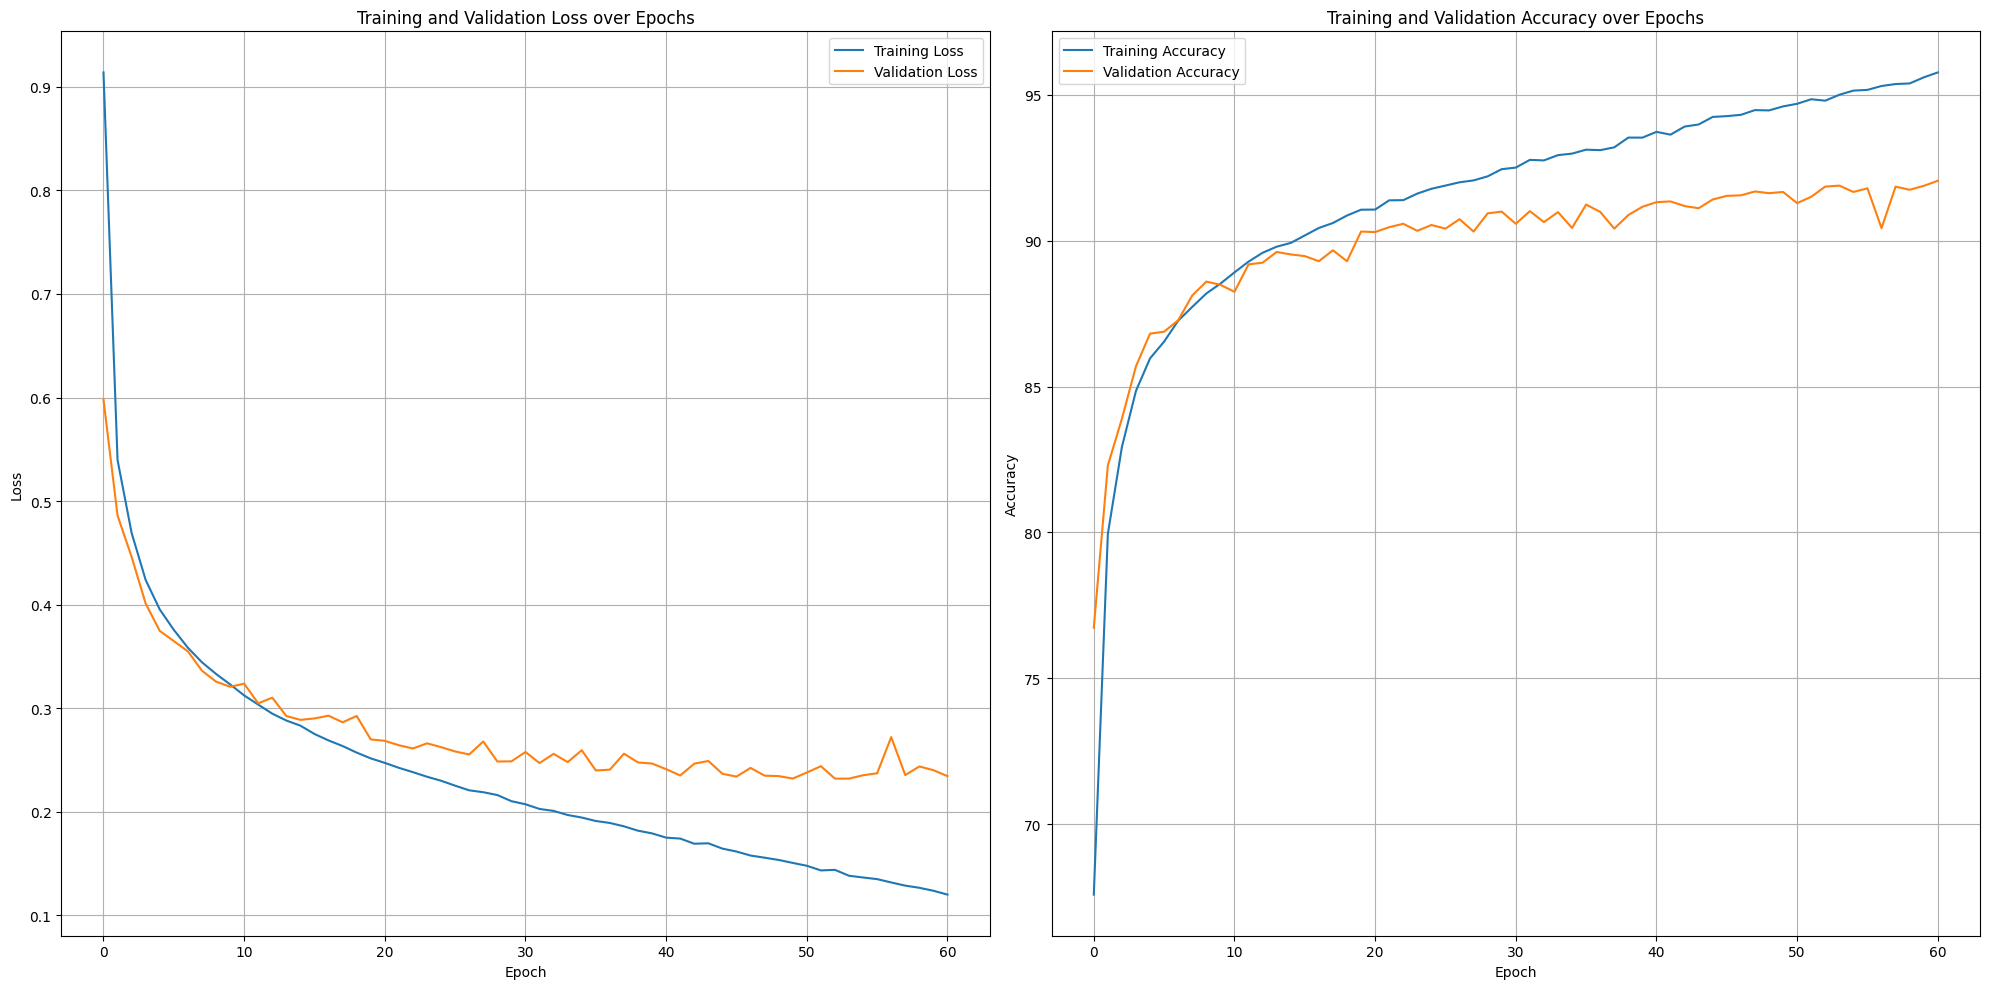

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss') 
plt.title('Training and Validation Loss over Epochs') 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy') 
plt.title('Training and Validation Accuracy over Epochs') 
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Training History Analysis**

The training curves clearly illustrate the model's learning dynamics:
- Initial Learning: Both Training Loss and Validation Loss decrease rapidly in the initial epochs, corresponding to a steep rise in both Training Accuracy and Validation Accuracy. This phase demonstrates the model efficiently learning the core patterns from the data.
- Overfitting Onset: After approximately epoch 10, the validation loss begins to decrease at a much slower rate, eventually stabilizing and showing minor fluctuations, while the training loss continues its steady descent. Simultaneously, the gap between training accuracy ($\approx \mathbf{95\%}$) and validation accuracy ($\approx \mathbf{91\%}$) widens significantly, confirming the onset of overfitting. The model starts memorizing noise or highly specific features in the training data that do not generalize.
- Early Stopping Efficacy: The training process successfully utilizes Early Stopping, halting training before $\mathbf{60}$ epochs when the validation loss fails to show sustained improvement. This ensures the model with the best generalization performance (lowest validation loss) is retained, effectively acting as a form of regularization.

**Convolutional Layer Filters Visualization**

Filter visualization provides insights into the feature hierarchy learned by the Convolutional Neural Network.
- Convolutional Filter: A convolutional filter (or kernel) is a small matrix of weights that slides across the input image to detect specific patterns, such as edges, corners, or textures. The filter weights are learned during training.
- Layer 1 Filters: Filters in the first convolutional layer (`conv1`) directly interact with the raw pixel data. Visualization of these filters typically reveals low-level feature detectors, such as $\mathbf{vertical, horizontal}$, or diagonal edges.
- Layer 2 Filters: Filters in the second convolutional layer (`conv2`) operate on the feature maps generated by the first layer. These filters often learn more complex, abstract, and compositional features by combining the low-level features detected in the previous layer.
- Visualization Method: The weights of the filters are extracted from the model, normalized for visualization, and displayed as small images. A diverging colormap (e.g., 'PuOr') is used to highlight positive (activating) and negative (inhibitory) weights within the filter.

/tmp/ipykernel_38/25570857.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Keep rect for overall figure padding


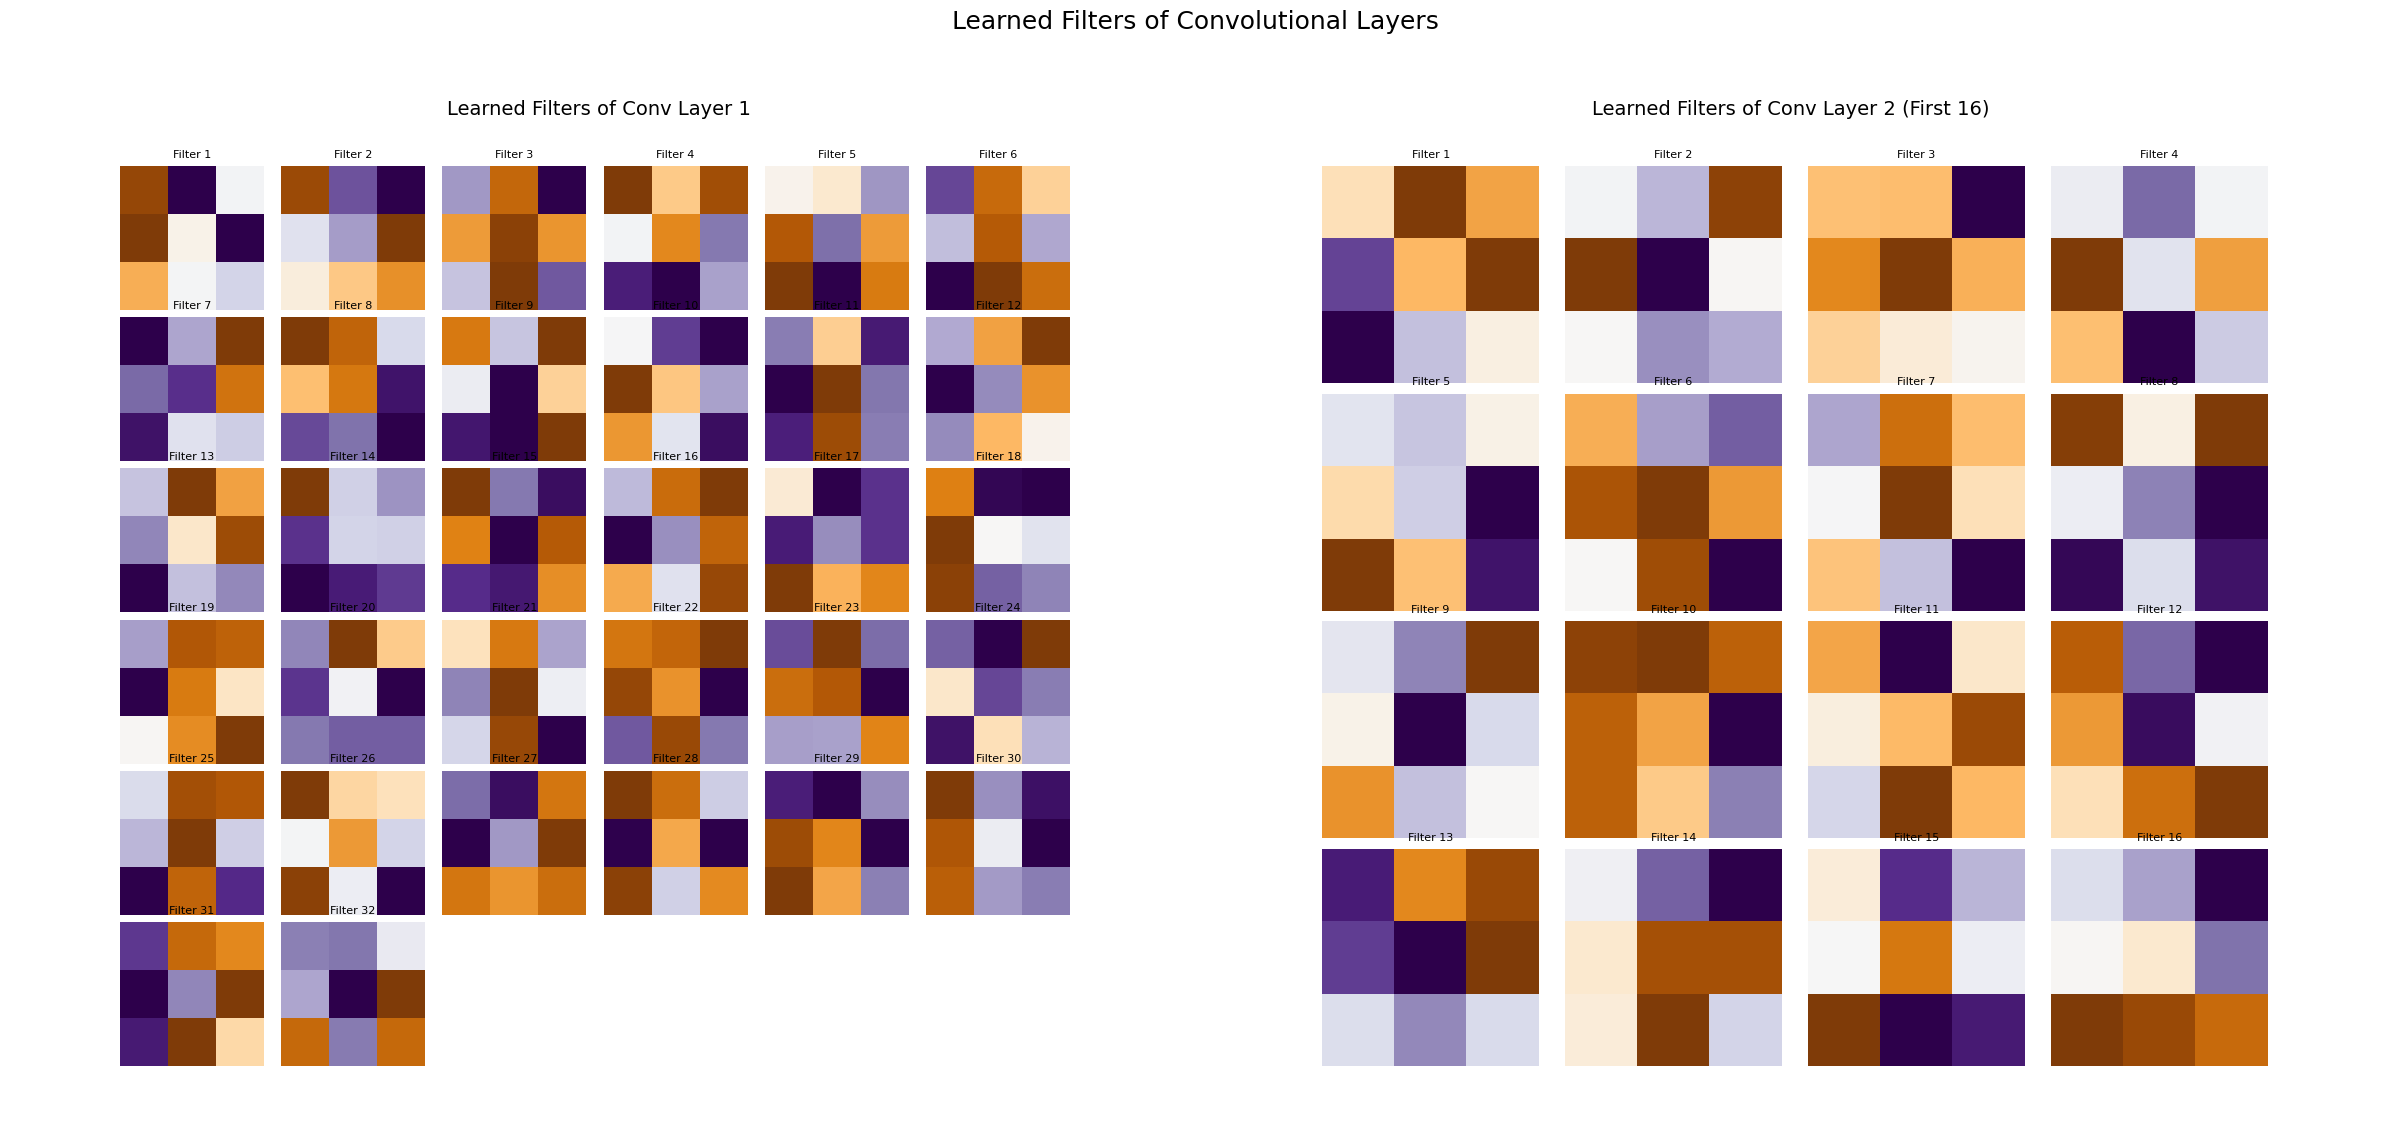

In [ ]:
model.to('cpu')

filters_conv1 = model.conv1.weight.data.clone().cpu().numpy()
num_filters_conv1 = filters_conv1.shape[0]

filters_conv2 = model.conv2.weight.data.clone().cpu().numpy()
num_filters_conv2 = filters_conv2.shape[0]

fixed_figsize = (24, 12)

fig, axes = plt.subplots(1, 2, figsize=fixed_figsize) 

ax1 = axes[0] 
ax1.set_title('Learned Filters of Conv Layer 1', fontsize=14, pad=20) 
ax1.axis('off') 

grid_cols_conv1 = int(np.ceil(np.sqrt(num_filters_conv1)))
grid_rows_conv1 = int(np.ceil(num_filters_conv1 / grid_cols_conv1))

gs1 = plt.GridSpec(grid_rows_conv1, grid_cols_conv1, figure=fig)
gs1.update(left=0.05, right=0.45, wspace=0.05, hspace=0.05, top=0.85, bottom=0.1) 

for i in range(num_filters_conv1):
    ax_filter1 = fig.add_subplot(gs1[i // grid_cols_conv1, i % grid_cols_conv1])
    filter_img = filters_conv1[i, 0, :, :] 
    min_val, max_val = filter_img.min(), filter_img.max()
    if max_val - min_val > 1e-6:
        filter_img = (filter_img - min_val) / (max_val - min_val)
    else:
        filter_img = np.zeros_like(filter_img)

    ax_filter1.imshow(filter_img, cmap='PuOr') 
    ax_filter1.set_title(f'Filter {i+1}', fontsize=8)
    ax_filter1.axis('off')

ax2 = axes[1] 
ax2.set_title('Learned Filters of Conv Layer 2 (First 16)', fontsize=14, pad=20)
ax2.axis('off') 

plot_filters_count_conv2 = min(16, num_filters_conv2)
grid_cols_conv2 = int(np.ceil(np.sqrt(plot_filters_count_conv2)))
grid_rows_conv2 = int(np.ceil(plot_filters_count_conv2 / grid_cols_conv2))

gs2 = plt.GridSpec(grid_rows_conv2, grid_cols_conv2, figure=fig)
gs2.update(left=0.55, right=0.95, wspace=0.05, hspace=0.05, top=0.85, bottom=0.1)

for i in range(plot_filters_count_conv2):
    ax_filter2 = fig.add_subplot(gs2[i // grid_cols_conv2, i % grid_cols_conv2])
    filter_img_conv2 = filters_conv2[i, :, :, :].mean(axis=0) 
    min_val, max_val = filter_img_conv2.min(), filter_img_conv2.max()
    if max_val - min_val > 1e-6:
        filter_img_conv2 = (filter_img_conv2 - min_val) / (max_val - min_val)
    else:
        filter_img_conv2 = np.zeros_like(filter_img_conv2)

    ax_filter2.imshow(filter_img_conv2, cmap='PuOr')
    ax_filter2.set_title(f'Filter {i+1}', fontsize=8)
    ax_filter2.axis('off')

fig.suptitle('Learned Filters of Convolutional Layers', fontsize=18, y=0.98) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

**Learned Filter Insights**

The visualization of convolutional filters confirms the functional principles of CNNs:
- Low-Level Features: The filters in $\mathbf{Conv\ Layer\ 1}$ show simple, localized patterns, such as detecting boundaries, contrasting light/dark regions, and simple directional edges. These are the foundational visual elements used to construct more complex features.
- Compositional Features: $\mathbf{Conv\ Layer\ 2}$ filters, while still abstract, appear to capture more intricate combinations of the low-level features, moving towards detecting larger patterns or textures. The increasing complexity of the learned features across layers is fundamental to the CNN's success in image classification.

**Decision Boundary (Latent Space) Visualization**

Latent space visualization is a powerful model interpretability tool that shows how the model organizes and separates the data in its feature space.
- Latent Space Concept: The "latent space" is represented here by the output of an intermediate dense layer (`fc_intermediate`), which contains the high-level, learned features before the final classification layer.
- Dimensionality Reduction (PCA): Since this latent space is high-dimensional ($\mathbf{64D}$), Principal Component Analysis ($\mathbf{PCA}$) is applied to project the features onto a $\mathbf{2D}$ plane (Principal Component 1 vs. Principal Component 2). PCA finds the directions (principal components) that capture the maximum variance in the data, making the 2D plot an effective proxy for the original separation.
- Decision Boundary Mapping: A meshgrid is created across the 2D PCA space, and its points are inverse-transformed back into the original 64D feature space. These reconstructed features are then fed through the model's final classification layer (`fc_output`) to predict the class at every point on the 2D plane.
- Plot Interpretation: The resulting plot overlays the predicted decision regions (colored areas) with the scatter points of the actual data, colored by their $\mathbf{true}$ and $\mathbf{predicted}$ classes. This directly visualizes the final classification logic and highlights the degree of class separation achieved by the CNN.


--- Visualizing CNN Latent Space (PCA of fc_intermediate output) on Training Data ---


/tmp/ipykernel_38/3164359716.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_regions = plt.cm.get_cmap('viridis', 10) # 10 classes


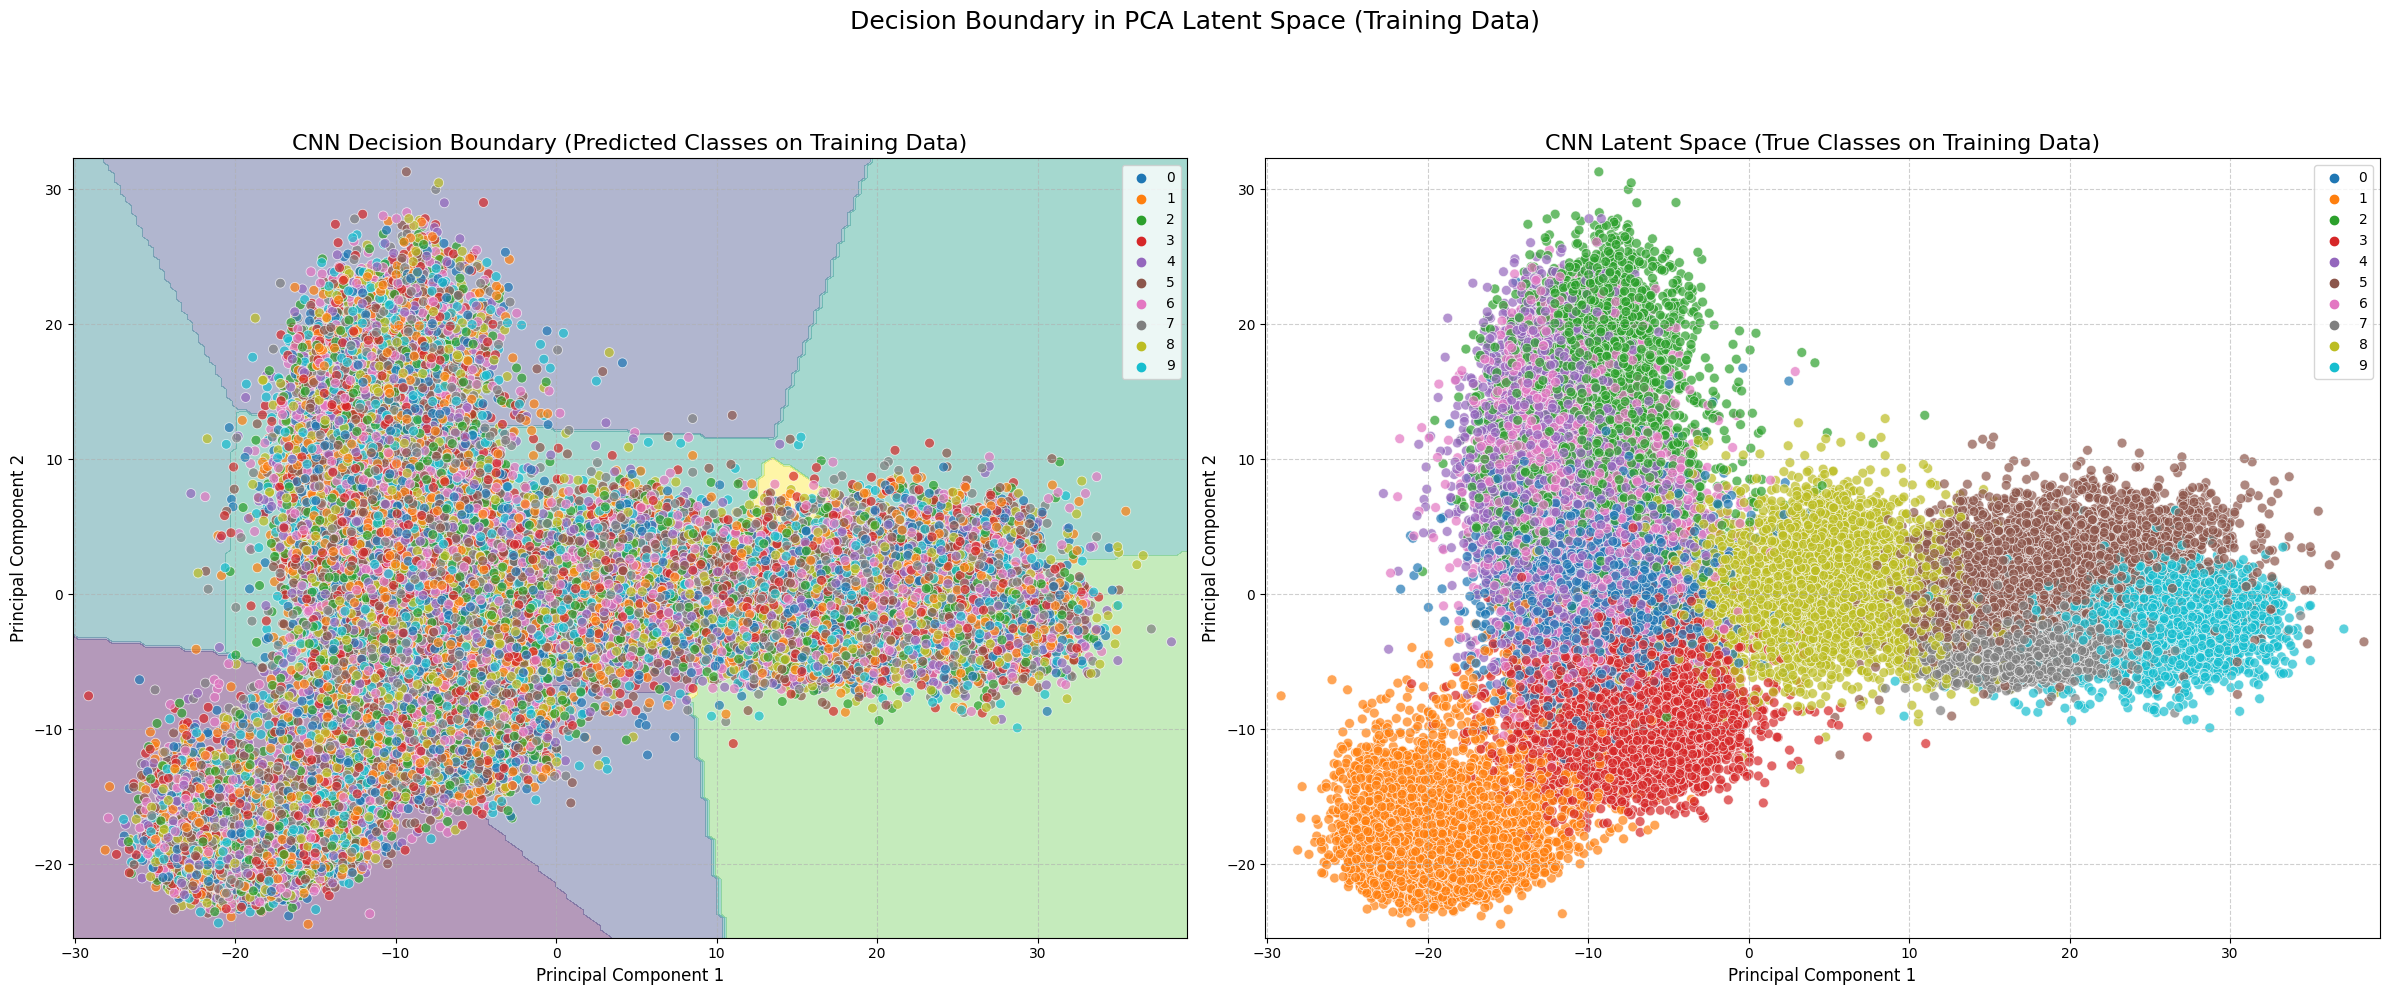

In [ ]:
print("\n--- Visualizing CNN Latent Space on Train Data ---")

def get_intermediate_features(model, dataloader, device):
    model.eval()
    features_list = []
    labels_list = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            x = model.pool1(model.relu1(model.conv1(images)))
            x = model.pool2(model.relu2(model.conv2(x)))
            x = x.view(-1, 64 * 7 * 7)
            x = model.relu3(model.fc1(x))
            intermediate_features = model.relu_intermediate(model.fc_intermediate(x))
            features_list.append(intermediate_features.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
    return np.vstack(features_list), np.hstack(labels_list)

model.to(device)

intermediate_features_train, true_labels_train = get_intermediate_features(model, train_loader, device)

pca = PCA(n_components=2)
pca.fit(intermediate_features_train)
pca_features_train = pca.transform(intermediate_features_train)

model.eval() 
all_preds_train = []
with torch.no_grad():
    for images, _ in train_loader:
        images = images.to(device) 
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_train.append(predicted.cpu().numpy())
predicted_labels_train = np.hstack(all_preds_train)

x_min, x_max = pca_features_train[:, 0].min() - 1, pca_features_train[:, 0].max() + 1
y_min, y_max = pca_features_train[:, 1].min() - 1, pca_features_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

meshgrid_points_2d = np.c_[xx.ravel(), yy.ravel()]
reconstructed_64d_features = pca.inverse_transform(meshgrid_points_2d)
reconstructed_64d_tensor = torch.tensor(reconstructed_64d_features, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    outputs_meshgrid = model.fc_output(reconstructed_64d_tensor)
    _, Z = torch.max(outputs_meshgrid.data, 1)
    Z = Z.cpu().numpy().reshape(xx.shape)

cmap_regions = plt.cm.get_cmap('viridis', 10)
cmap_scatter = sns.color_palette("tab10", n_colors=10)
fig_db, axes_db = plt.subplots(1, 2, figsize=(24, 10)) 

ax_db1 = axes_db[0]
contourf_plot = ax_db1.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_regions)
sns.scatterplot(
    x=pca_features_train[:, 0],
    y=pca_features_train[:, 1],
    hue=predicted_labels_train,
    palette=cmap_scatter,
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax_db1
)
ax_db1.set_title('CNN Decision Boundary (Predicted Classes on Training Data)', fontsize=16)
ax_db1.set_xlabel('Principal Component 1', fontsize=12)
ax_db1.set_ylabel('Principal Component 2', fontsize=12)
ax_db1.grid(True, linestyle='--', alpha=0.6)
ax_db1.set_xlim(xx.min(), xx.max())
ax_db1.set_ylim(yy.min(), yy.max())

ax_db2 = axes_db[1]
sns.scatterplot(
    x=pca_features_train[:, 0], 
    y=pca_features_train[:, 1], 
    hue=true_labels_train, 
    palette=cmap_scatter,
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax_db2 
)
ax_db2.set_title('CNN Latent Space (True Classes on Training Data)', fontsize=16)
ax_db2.set_xlabel('Principal Component 1', fontsize=12)
ax_db2.set_ylabel('Principal Component 2', fontsize=12)
ax_db2.grid(True, linestyle='--', alpha=0.6)
ax_db2.set_xlim(xx.min(), xx.max())
ax_db2.set_ylim(yy.min(), yy.max())

fig_db.suptitle('Decision Boundary in PCA Latent Space (Training Data)', fontsize=18, y=1.02) 
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

**Latent Space and Decision Boundary**

The PCA projection of the latent space reveals the effectiveness of the feature extraction process:
- Excellent Separation: The true classes are highly clustered and distinctly separated in the 2D PCA space. The features learned by the `fc_intermediate` layer are highly discriminative, successfully pulling apart the different clothing categories.
- Clear Classification: The $\mathbf{Trouser}$ class (1, orange) and the footwear classes ($\mathbf{Sandal}$ (5), $\mathbf{Sneaker}$ (7), $\mathbf{Ankle\ boot}$ (9)) form large, distinct clusters far from the top wear items. This suggests the model easily distinguishes between these broad categories.
- Confusable Boundaries: A region of significant overlap and mixing is observed, primarily involving the classes $\mathbf{T-shirt/top}$ (0), $\mathbf{Pullover}$ (2), $\mathbf{Dress}$ (3), $\mathbf{Coat}$ (4), and $\mathbf{Shirt}$ (6). This visual confusion in the latent space aligns with the initial qualitative observation from the sample images and predicts where most classification errors (misclassifications) will occur in the Confusion Matrix.
- Decision Logic: The CNN Decision Boundary plot demonstrates that the model's classification regions generally align well with the distinct data clusters, confirming that the linear classification layers effectively leverage the highly-separated features produced by the preceding convolutional layers.

# Model Evaluation

This stage involves assessing the final trained model's performance on the unseen test dataset and interpreting key classification metrics and visualizations.

**Model Evaluation and Performance Metrics**

A comprehensive evaluation requires more than simple accuracy; a suite of metrics is used to understand the model's strengths and weaknesses across all classes.
- Final Test Accuracy: The trained model, loaded with the best weights identified by Early Stopping, is run on the independent test dataset. The final test accuracy provides an unbiased estimate of the model's expected performance in a real-world scenario.
- Classification Metrics: Since the dataset is balanced, Accuracy is a reliable overall measure. However, for a multi-class problem, metrics like $\mathbf{Precision}$, $\mathbf{Recall}$, and $\mathbf{F1-score}$ are calculated using the $\mathbf{macro}$ averaging method. Macro averaging computes the metric independently for each class and then takes the average, treating all classes equally regardless of the sample size.
- AUC-ROC (Area Under the Receiver Operating Characteristic Curve): The AUC-ROC is calculated using the $\mathbf{One-vs-Rest}$ ($\mathbf{OvR}$) approach for multi-class classification. This metric assesses the model's ability to distinguish between a specific class and all other classes combined. A value close to $\mathbf{1.0}$ indicates excellent separability.
- Classification Report: This report synthesizes the Precision, Recall, and F1-score for each individual class, providing granular detail on the model's performance on specific clothing items.

**Evaluation on Test Dataset**

In [ ]:
print("\n--- Evaluation on Test Dataset ---")
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    final_accuracy = 100 * correct / total
    print(f'Final Test Accuracy of the CNN model: {final_accuracy:.2f}%')
print("="*40 + "\n")


--- Final Evaluation on Test Set ---
Final Test Accuracy of the CNN model: 92.34%



**Confusion Matrix**

The Confusion Matrix is a vital tool for visualizing the outcomes of a classification model and identifying misclassification patterns.
- Matrix: The matrix plots the True\ Label (rows) against the Predicted Label (columns). The diagonal elements represent correct classifications (where True Label equals Predicted Label). Off-diagonal elements represent misclassifications.
- Interpretation Focus: The analysis of the confusion matrix focuses on:High Diagonal Values: Confirmation of high accuracy for well-separated classes.
- Off-Diagonal Clusters: Identification of classes that are frequently confused with each other, which points to inherent visual similarity or ambiguity in the data itself.

In [ ]:
print("\n--- Final Evaluation on Test Set and Performance Metrics ---")
model.eval()
all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

y_true_test_np = np.array(all_labels)
y_pred_test_np = np.array(all_predictions)
y_pred_proba_test_np = np.array(all_probabilities)

# Calculate metrics
cm = confusion_matrix(y_true_test_np, y_pred_test_np)
accuracy = accuracy_score(y_true_test_np, y_pred_test_np)
precision = precision_score(y_true_test_np, y_pred_test_np, average='macro', zero_division=1)
recall = recall_score(y_true_test_np, y_pred_test_np, average='macro', zero_division=1)
f1 = f1_score(y_true_test_np, y_pred_test_np, average='macro', zero_division=1)
roc_auc_val = roc_auc_score(y_true_test_np, y_pred_proba_test_np, multi_class='ovr')

# Print the results
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision (macro): {precision:.3f}")
print(f"Recall (macro): {recall:.3f}")
print(f"F1-score (macro): {f1:.3f}")
print(f"AUC-ROC (OvR): {roc_auc_val:.3f}")

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_true_test_np, y_pred_test_np, zero_division=1))
print("="*40 + "\n")


--- Final Evaluation on Test Set and Performance Metrics ---
Accuracy: 0.923
Precision (macro): 0.925
Recall (macro): 0.923
F1-score (macro): 0.924
AUC-ROC (OvR): 0.996

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      1000
           1       0.99      0.99      0.99      1000
           2       0.91      0.85      0.88      1000
           3       0.91      0.95      0.93      1000
           4       0.88      0.89      0.89      1000
           5       0.99      0.98      0.98      1000
           6       0.76      0.83      0.79      1000
           7       0.96      0.95      0.96      1000
           8       0.99      0.98      0.99      1000
           9       0.95      0.98      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000




**Overall Performance Metrics**

The model achieved a high level of overall performance on the unseen test data.
- High Accuracy: The Final Test Accuracy of $\mathbf{92.34\%}$ and Macro F1-score of $\mathbf{0.924}$ indicate that the CNN successfully learned discriminative features. The high $\mathbf{AUC-ROC}$ of $\mathbf{0.996}$ confirms the model's excellent capability in separating classes.
- Balanced Performance: The similar values for Precision ($\mathbf{0.925}$), Recall ($\mathbf{0.923}$), and F1-score ($\mathbf{0.924}$) indicate that the model performs consistently across the different types of classification errors (false positives vs. false negatives).

**Confusion metrics**

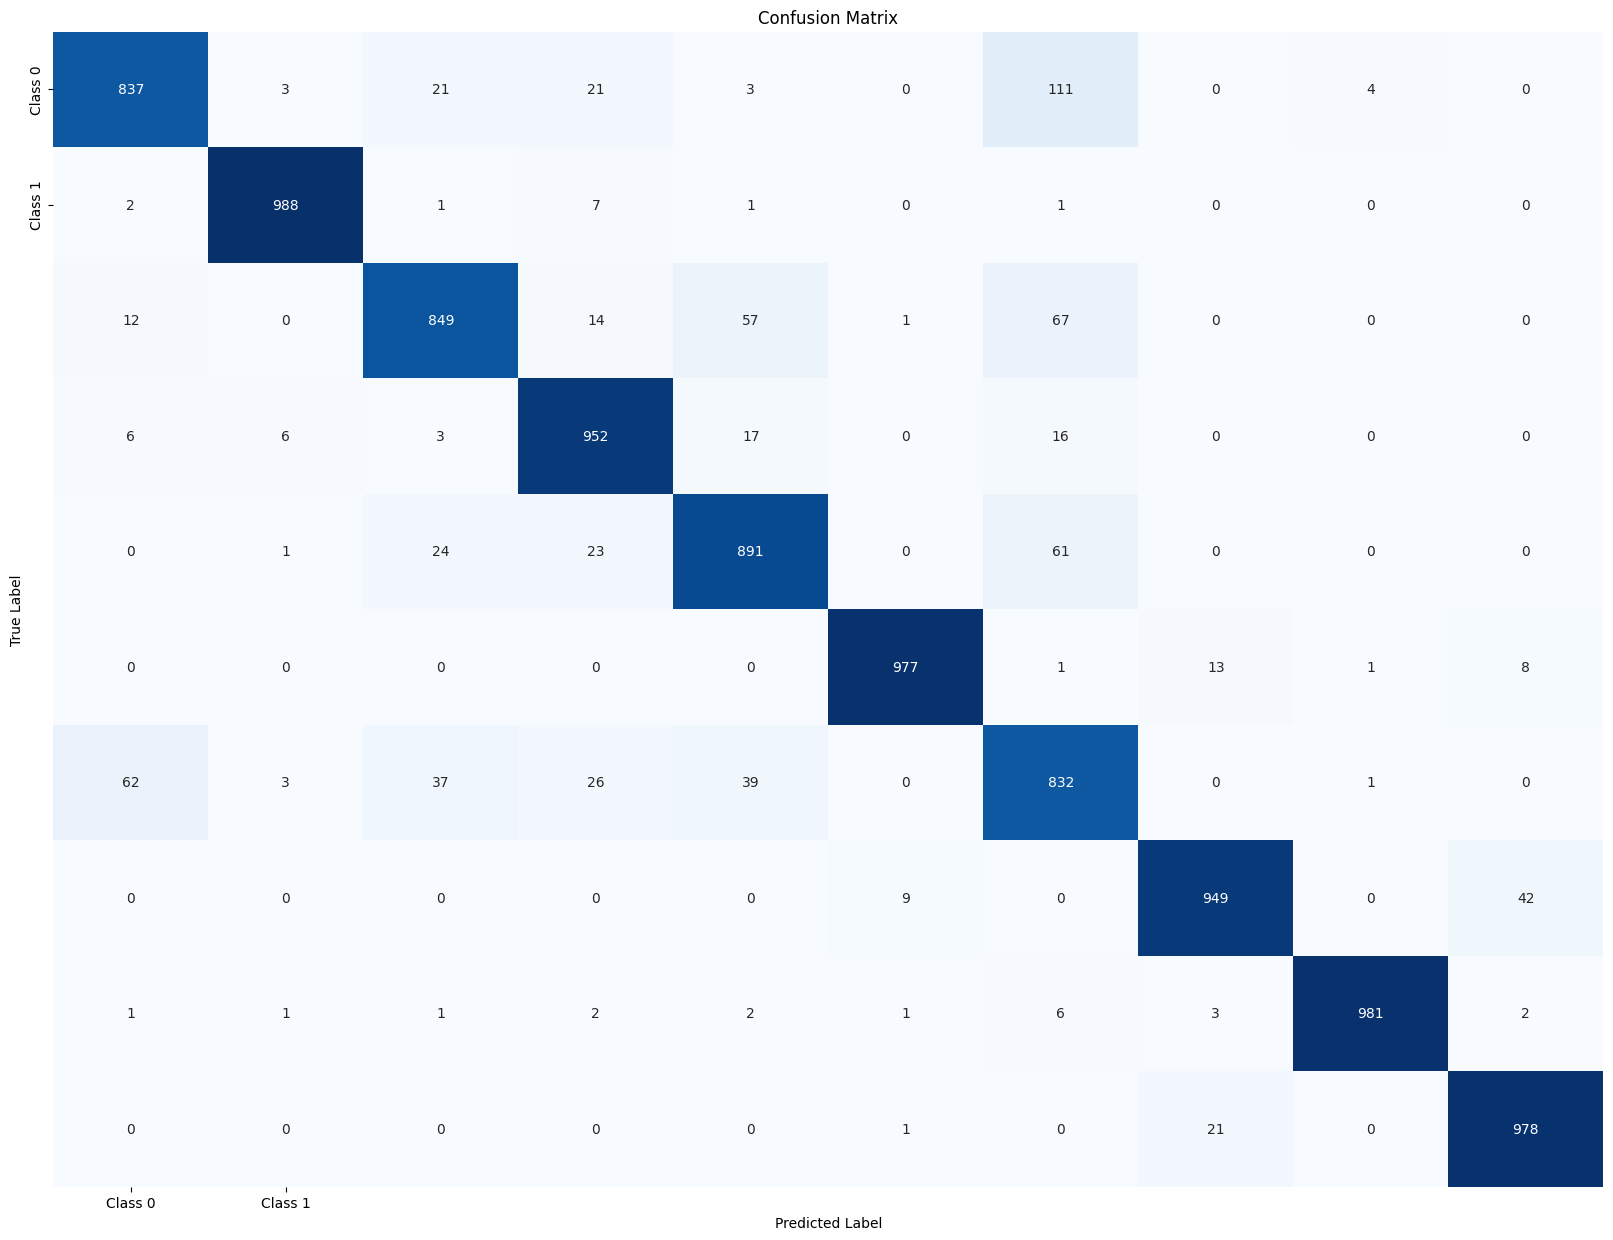

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Misclassification Patterns (Confusion Matrix)**

The Confusion Matrix highlights specific ambiguities in the dataset:
- Well-Separated Classes: Classes like $\mathbf{Trouser}$ (1), $\mathbf{Sandal}$ (5), $\mathbf{Bag}$ (8), and $\mathbf{Ankle\ boot}$ (9) show exceptionally high recall ($\mathbf{0.98}-\mathbf{0.99}$) and F1-scores ($\mathbf{0.98}-\mathbf{0.99}$). These items have unique and consistent shapes, making them easy to identify.
- Confused Classes ($\mathbf{Shirt}$): The category Class 6 ($\mathbf{Shirt}$) exhibits the lowest performance, with a low $\mathbf{Recall}$ ($\mathbf{0.83}$) and the lowest $\mathbf{Precision}$ ($\mathbf{0.76}$). The matrix shows that $\mathbf{Shirt}$ is frequently misclassified as Class 0 ($\mathbf{T-shirt/top}$) and Class 4 ($\mathbf{Coat}$), and vice versa. This confirms the visual similarity between different types of top wear, which share basic outlines and features.
- Confused Classes ($\mathbf{Pullover}$): Class 2 ($\mathbf{Pullover}$) also shows lower performance, with a recall of $\mathbf{0.85}$, primarily being confused with $\mathbf{Class 0}$ and $\mathbf{Class 4}$.

**Precision-Recall Curve**

The Precision-Recall Curve (PR Curve) plots the trade-off between Precision and Recall for different threshold settings.
- PR Curve: Unlike the ROC curve, which is often insensitive to class imbalance, the PR curve provides a better measure of performance when dealing with classification tasks where the cost of false negatives or false positives is crucial. Each class's curve is generated using the $\mathbf{One-vs-Rest}$ method.
- AUC-PR (Area Under the Curve): The area under the PR curve summarizes performance, with an AUC close to $\mathbf{1.0}$ indicating a classifier that can maintain high recall without sacrificing precision. The class-wise AUC values pinpoint which clothing categories the model predicts with the highest confidence and reliability.


--- Plotting Precision-Recall Curve ---


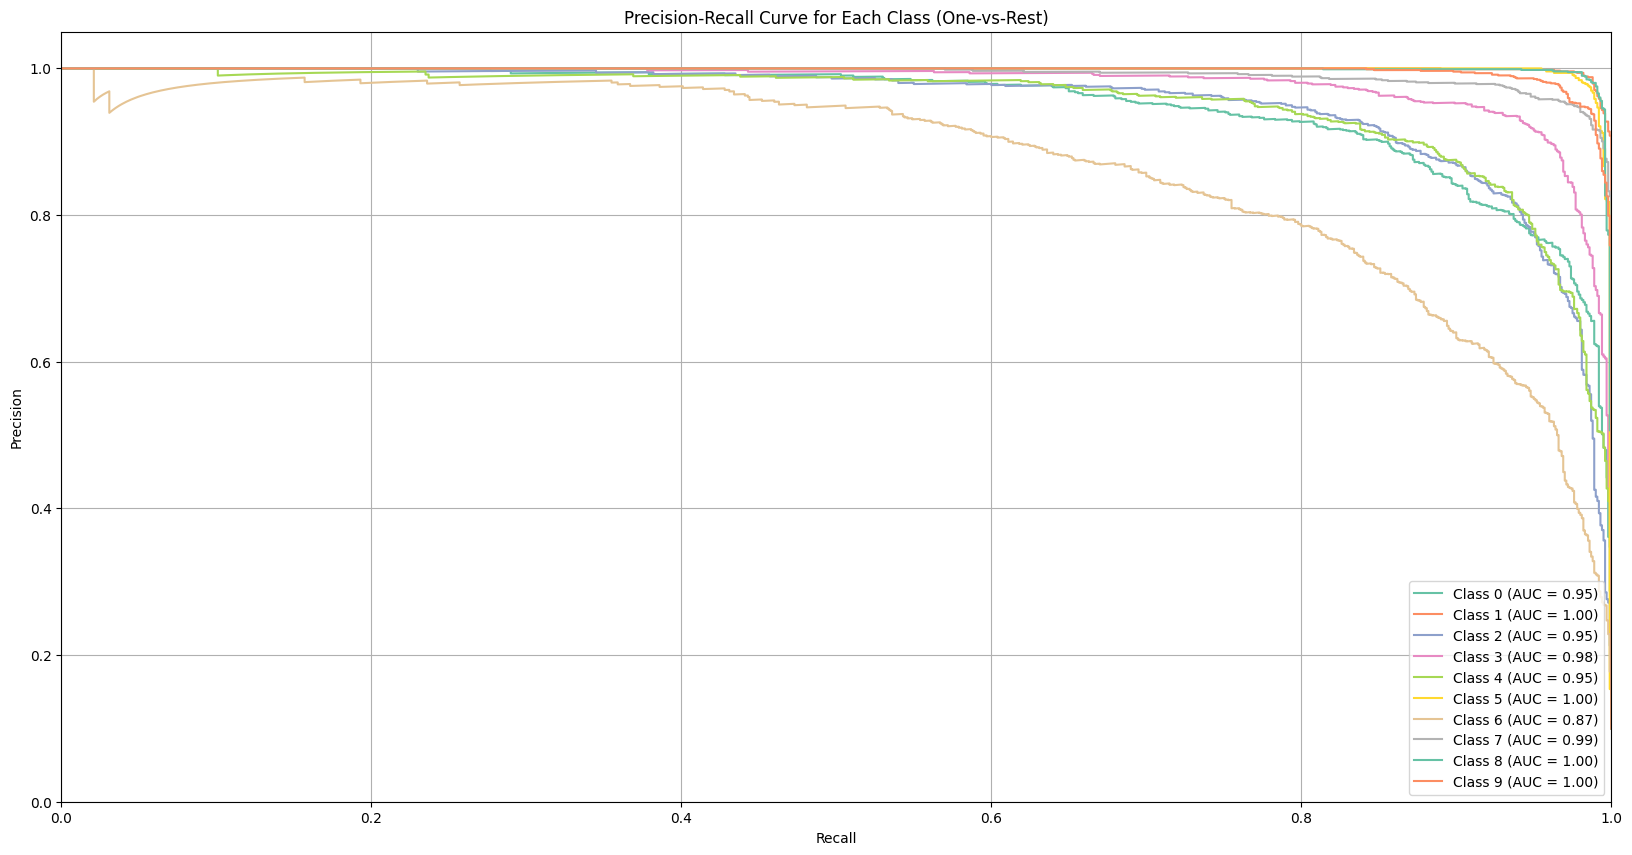

In [ ]:
print("\n--- Plotting Precision-Recall Curve ---")

num_classes_pr = model.fc_output.out_features
class_labels_pr = [str(i) for i in range(num_classes_pr)]

plt.figure(figsize=(20, 10))

sns.set_palette("Set2")

for i, label_str in enumerate(class_labels_pr):
    class_val = int(label_str)
    y_test_bin = np.where(y_true_test_np == class_val, 1, 0)
    y_pred_score = y_pred_proba_test_np[:, class_val]
    precision, recall, _ = precision_recall_curve(y_test_bin, y_pred_score)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {label_str} (AUC = {pr_auc:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Class (One-vs-Rest)")
plt.legend(loc="lower right")
plt.ylim([0, 1.05])
plt.xlim([0, 1])
plt.grid(True) 

plt.show()

**Precision-Recall Curve**

The PR curve confirms the class-wise performance differences:
- High Confidence Classes: Classes $\mathbf{1, 5, 8, 9}$ (Trouser, Sandal, Bag, Ankle boot) achieve an AUC-PR of $\mathbf{1.00}$, signifying that the model can maintain near-perfect precision across all recall levels for these highly distinct items.
- Challenging Class: Class 6 ($\mathbf{Shirt}$) has the lowest AUC-PR of $\mathbf{0.87}$. The curve for Class 6 is the steepest and drops earliest, indicating that as the model attempts to increase its recall for Shirts, its precision (the proportion of correct positive predictions) drops significantly.

**Latent Space Visualization**

Repeating the latent space visualization on the test data confirms the generalization ability of the features learned by the CNN.
- Generalization Check: This visualization ensures that the feature clustering and separation observed on the training data are maintained on entirely new, unseen data.
- Consistency: The PCA projection of the $\mathbf{64D}$ intermediate features from the test set is plotted, alongside the decision boundaries, confirming whether the classification regions established during training align correctly with the test data clusters. Any significant divergence between the true class clusters on the test set and the predicted decision regions would suggest a failure in generalization.


--- Visualizing CNN Latent Space (PCA of fc_intermediate output) on Test Data ---


/tmp/ipykernel_38/3567315073.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_regions = plt.cm.get_cmap('viridis', 10) # 10 classes


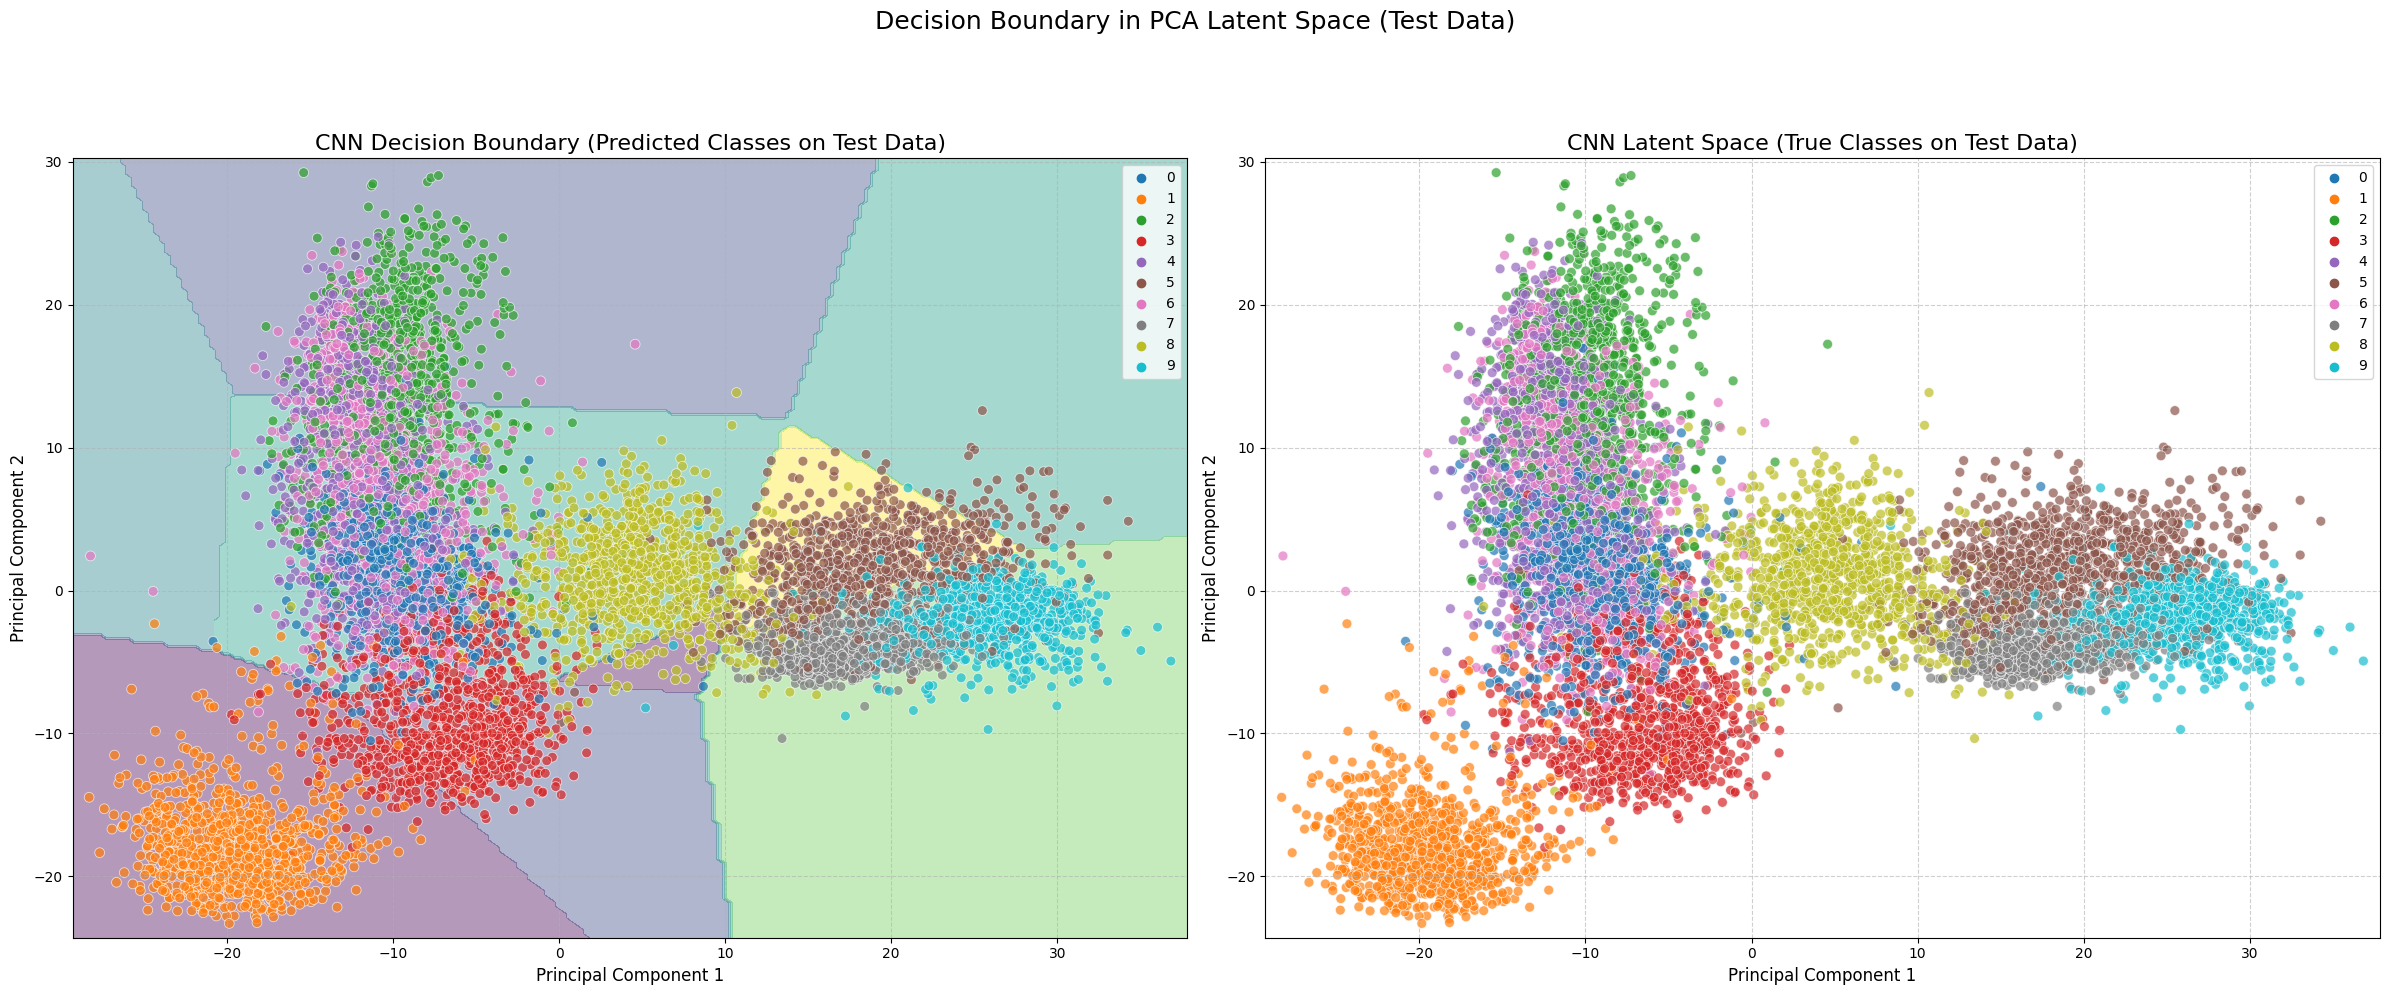

In [ ]:
print("\n--- Visualizing CNN Latent Space on Test Data ---")

def get_intermediate_features(model, dataloader, device):
    model.eval()
    features_list = []
    labels_list = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device) 
            x = model.pool1(model.relu1(model.conv1(images)))
            x = model.pool2(model.relu2(model.conv2(x)))
            x = x.view(-1, 64 * 7 * 7) 
            x = model.relu3(model.fc1(x)) 
            intermediate_features = model.relu_intermediate(model.fc_intermediate(x))
            features_list.append(intermediate_features.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
    return np.vstack(features_list), np.hstack(labels_list)

model.to(device)

intermediate_features_test, true_labels_test = get_intermediate_features(model, test_loader, device)

pca = PCA(n_components=2)
pca.fit(intermediate_features_test)
pca_features_test = pca.transform(intermediate_features_test)

model.eval() 
all_preds_test = []
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device) 
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.append(predicted.cpu().numpy())
predicted_labels_test = np.hstack(all_preds_test)

x_min, x_max = pca_features_test[:, 0].min() - 1, pca_features_test[:, 0].max() + 1
y_min, y_max = pca_features_test[:, 1].min() - 1, pca_features_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
meshgrid_points_2d = np.c_[xx.ravel(), yy.ravel()]
reconstructed_64d_features = pca.inverse_transform(meshgrid_points_2d)
reconstructed_64d_tensor = torch.tensor(reconstructed_64d_features, dtype=torch.float32).to(device)

model.eval()

with torch.no_grad():
    outputs_meshgrid = model.fc_output(reconstructed_64d_tensor)
    _, Z = torch.max(outputs_meshgrid.data, 1)
    Z = Z.cpu().numpy().reshape(xx.shape)

cmap_regions = plt.cm.get_cmap('viridis', 10)
cmap_scatter = sns.color_palette("tab10", n_colors=10)
fig_db, axes_db = plt.subplots(1, 2, figsize=(24, 10))

ax_db1 = axes_db[0]
contourf_plot = ax_db1.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_regions)
sns.scatterplot(
    x=pca_features_test[:, 0],
    y=pca_features_test[:, 1],
    hue=predicted_labels_test,
    palette=cmap_scatter,
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax_db1
)
ax_db1.set_title('CNN Decision Boundary (Predicted Classes on Test Data)', fontsize=16)
ax_db1.set_xlabel('Principal Component 1', fontsize=12)
ax_db1.set_ylabel('Principal Component 2', fontsize=12)
ax_db1.grid(True, linestyle='--', alpha=0.6)
ax_db1.set_xlim(xx.min(), xx.max())
ax_db1.set_ylim(yy.min(), yy.max())

ax_db2 = axes_db[1]
sns.scatterplot(
    x=pca_features_test[:, 0], 
    y=pca_features_test[:, 1], 
    hue=true_labels_test, 
    palette=cmap_scatter,
    legend='full',
    alpha=0.7,
    s=50,
    ax=ax_db2 
)
ax_db2.set_title('CNN Latent Space (True Classes on Test Data)', fontsize=16) 
ax_db2.set_xlabel('Principal Component 1', fontsize=12)
ax_db2.set_ylabel('Principal Component 2', fontsize=12)
ax_db2.grid(True, linestyle='--', alpha=0.6)
ax_db2.set_xlim(xx.min(), xx.max())
ax_db2.set_ylim(yy.min(), yy.max())

fig_db.suptitle('Decision Boundary in PCA Latent Space (Test Data)', fontsize=18, y=1.02) 
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Latent Space Generalization**

The latent space visualization on the test data mirrors the findings from the training data:
- Consistent Separation: The test data points, when projected by PCA, form clusters that are almost identical in structure and separation to the training data. This demonstrates that the CNN's feature extraction capability successfully $\mathbf{generalized}$ to new data.
- Decision Boundary Fit: The decision regions map onto the test clusters effectively, but the region of overlap, particularly between the top-wear items (Classes 0, 2, 4, 6), remains the primary source of inter-class confusion, confirming that the classification errors are due to inherent data ambiguity rather than model overfitting.

# References

- [Convolutional Neural Networks (CNN) — Architecture Explained](https://medium.com/@draj0718/convolutional-neural-networks-cnn-architectures-explained-716fb197b243)
- [Convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network)
- [An Introduction to Convolutional Neural Networks](https://arxiv.org/abs/1511.08458)
- [Introduction to Convolution Neural Network](https://www.geeksforgeeks.org/machine-learning/introduction-convolution-neural-network/)
- [Convolutional Neural Network (CNN) TensorFlow](https://www.tensorflow.org/tutorials/images/cnn)
- [Convolutional Neural Networks cheatsheet](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks)
- [Comprehensive Guide to CNN with Keras](https://www.kaggle.com/code/prashant111/comprehensive-guide-to-cnn-with-keras)
- [Training an image classifier](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)
- [PyTorch CNN Tutorial: Build and Train Convolutional Neural Networks in Python](https://www.datacamp.com/tutorial/pytorch-cnn-tutorial)
- [Building a Convolutional Neural Network using PyTorch](https://www.geeksforgeeks.org/deep-learning/building-a-convolutional-neural-network-using-pytorch/)